# Error correction with cat qubits

A central obstacle to building useful quantum computers is the prevalence of hardware-level noise, which corrupts quantum information long before meaningful computations can be completed. Quantum error correction addresses this challenge by encoding a single logical qubit across many noisy physical qubits, allowing errors to be detected and corrected without destroying the encoded information.

Dissipative cat qubits encode one logical qubit in the phase space of a quantum harmonic oscillator, also known as a bosonic mode. As the average photon number increases, the phase-flip error rate of a cat qubit can be suppressed exponentially, while the bit-flip error rate grows only linearly [[REF](https://arxiv.org/pdf/1907.11729)]. This asymmetry enables access to regimes of strong noise bias, where phase-flip errors can, in principle, be made arbitrarily rare, leaving bit-flip errors as the dominant remaining failure mode.

This noise bias can be exploited by concatenating cat qubits with higher-level quantum error-correcting codes that are optimized to suppress bit-flip errors. The result is a substantial reduction in the number of physical resources required to achieve fault-tolerant quantum computation, compared to architectures based on unbiased qubits.

In this challenge, you will explore how cat qubits enable significant reductions in hardware overhead for fault-tolerant quantum computing. You will also investigate novel error-correcting codes that are particularly well suited for concatenation with cat qubits, further reducing complexity and resource requirements.

**NOTE:** All subtasks in this notebook are marked with `[TODO]`. You can use Ctrl/Cmd+F to find them and make sure you do not miss any. In some places, you will also see sections labeled `# SOLUTION ===`, which indicate where you should add code to complete the task.

# 1 - Installations


Begin by uncommenting and running the cell below to install the dependencies needed for this challenge.

In [1]:
!pip install stim~=1.15
!pip install numpy~=1.0  # 1.0 instead of 2.0 for pymatching compatibility later
!pip install scipy
!pip install pymatching~=2.0
!pip install sinter~=1.14


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import stim
import pymatching
import sinter
from typing import List
import matplotlib.pyplot as plt
import os
import numpy as np
import math

# Monkey-patch: sinter 1.15 asserts `isinstance(errors, int)` but pymatching
# returns numpy.int64 when used with numpy 2.x.  Cast all numeric fields to
# plain Python ints/floats so the assertion passes.
# Use object.__setattr__ because AnonTaskStats is a frozen dataclass.
import sinter._data._anon_task_stats as _ats
def _patched_post_init(self):
    object.__setattr__(self, 'shots', int(self.shots))
    object.__setattr__(self, 'errors', int(self.errors))
    object.__setattr__(self, 'discards', int(self.discards))
_ats.AnonTaskStats.__post_init__ = _patched_post_init

print(stim.__version__)

1.15.0


# 2 - Bell states & Error Detection Codes

The following section demonstrates the creation and measurement of a bell state:

$$ \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Then, we will use bell states as codewords for the smallest error detection code.

In [3]:
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair.
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])

# Then, the circuit will measure both qubits of the Bell pair in the Z basis.
circuit.append("M", [0, 1])

H 0
CX 0 1
M 0 1

q0: -H-@-M:rec[0]-
       |
q1: ---X-M:rec[1]-



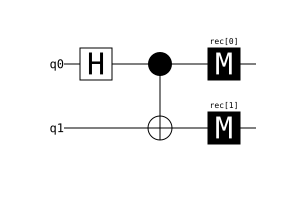

In [4]:
print(circuit)
print("")
print(circuit.diagram())
print("")
circuit.diagram('timeline-svg')

Now, we can sample this circuit and, in doing so, measure the state of each qubit.

In [5]:
sampler = circuit.compile_sampler()
sampler.sample(shots=10)

array([[False, False],
       [False, False],
       [ True,  True],
       [False, False],
       [False, False],
       [ True,  True],
       [ True,  True],
       [False, False],
       [ True,  True],
       [False, False],
       [False, False]])

Here, False means 0 and True means 1. Notice how the results of the measurement qubit 0 and the measurement on qubit 1 always match, as expected of a bell state. So, we can expect a parity measurement between the two qubits to always be 0, since the two qubits will always have the same state. In stim, the parity is measured using a "DETECTOR" operation, as shown below:

In [6]:
circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2)])
print(repr(circuit))

stim.Circuit('''
    H 0
    CX 0 1
    M 0 1
    DETECTOR rec[-1] rec[-2]
''')


In [7]:
sampler = circuit.compile_detector_sampler()
print(sampler.sample(shots=5))

[[False]
 [False]
 [False]
 [False]
 [False]]


Now, let's add X errors onto each qubit.

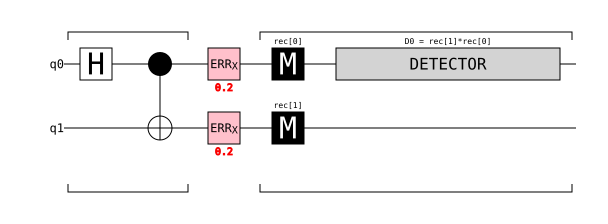

In [8]:
p = 0.2
circuit = stim.Circuit(f"""
    H 0
    CX 0 1
    
    TICK
    X_ERROR({p}) 0 1
    TICK

    M 0 1
    DETECTOR rec[-1] rec[-2]
""")

circuit.diagram('timeline-svg')

In [9]:
sampler = circuit.compile_detector_sampler()
print(sampler.sample(shots=10))

[[False]
 [False]
 [False]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [False]
 [False]]


With stim, we can quickly collect many samples, extracting the detector hit rate, which should be:

$$p*(1-p)*2$$

In [10]:
import numpy as np
print(np.sum(sampler.sample(shots=10**6)) / 10**6)
print(p*(1-p)*2)

0.320579
0.32000000000000006


## Task 2.1: Error detection code

[TODO, 10pts]: As shown, in the absence of noise the parity between the two qubits in a Bell state is fixed.

The presence of a single-qubit bit-flip error changes this parity, which appears as a nonzero detector outcome when the stabilizer $Z_0 Z_1$ is measured. This observation can be used to construct the simplest quantum error-detecting code, the two-qubit code $[[2,1,1]]$. In the notation $[[n,k,d]]$, $n$ is the number of physical qubits, $k$ is the number of logical qubits, and $d$ is the code distance. The distance $d$ is the minimum weight of a Pauli operator that preserves the codespace while acting nontrivially on the logical information.

You will now implement a $[[2,1,1]]$ code using two data qubits and one ancilla qubit to measure the stabilizer $Z_0 Z_1$. A convenient choice of logical basis states within the codespace is

$$
\ket{0_L} = \ket{\Phi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}, \qquad
\ket{1_L} = \ket{\Phi^-} = \frac{\ket{00} - \ket{11}}{\sqrt{2}}.
$$

Assume that each data qubit undergoes an independent $X$ error with probability $p = 0.1$. An odd number of bit flips anticommutes with $Z_0 Z_1$ and is therefore detected by the parity check. By postselecting on runs with a trivial detector outcome (i.e. detector = False), all such odd-parity leakage error events are removed. These are denoted leakage errors, as they take the qubits out of the codespace, spanned by superpositions of the codewords. 


As a result, postselection suppresses all first-order physical bit-flip errors. The only remaining error process on the accepted runs is the even-parity event $X_0 X_1$, which is a logical identity operator as both codewords are in its +1 eigenbasis. 

Set up this code, simulate it with X errors on each data qubit after the preparation of a bell state, and show that leakage errors and logical errors are fully suppressed with postselection on no detector events. Calculate the success probability of no detector errors occurring as a function of the physical error rate $p$ and show that it matches your simulation.

In [11]:
# SOLUTION ===
# initialize stim circuit needed for this simulation

# ===
p= 0.1
circuit = stim.Circuit(f"""
H 0 2
CNOT 0 1
TICK                 
X_ERROR({p}) 0 1
TICK
CZ 2 0
CZ 2 1
H 2
TICK
M 0 1 2
TICK
DETECTOR rec[-1]
DETECTOR rec[-2] rec[-3]
""")

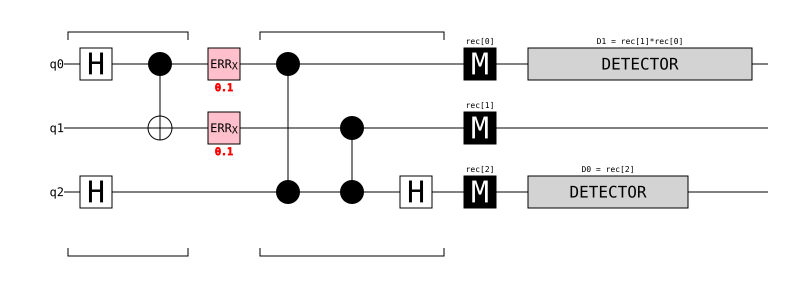

In [12]:
circuit.diagram('timeline-svg')

In [13]:
# SOLUTION ===
# run/sample simulation to calculated a simulated logical error rate

shots = 10**6
dsampler = circuit.compile_detector_sampler()
print(dsampler.sample(shots=shots))
counter = 0
list = []
for x in dsampler.sample(shots=shots):
    if(x[0] == x[1]):
        counter += 1

print(f"Compatible error prediction: {counter}")
import numpy as np

simulated_logical_error_rate = np.sum(dsampler.sample(shots=shots)[:, 0]) / shots
print(f"Simulates logical error rate: {simulated_logical_error_rate}")

# ===

[[False False]
 [False False]
 [False False]
 ...
 [ True  True]
 [False False]
 [ True  True]]
Compatible error prediction: 1000000
Simulates logical error rate: 0.180612


In [14]:
p = 0.1
success_prob = 1 - p*(1-p)*2
print("success probability:", success_prob, 1-simulated_logical_error_rate)

success probability: 0.82 0.819388


# 3 - Repetition Code

## Task 3.1 Implement a decoder for the repetition code.

[TODO, 5pts]: You will now implement and simulate the $n$-qubit repetition code with asymmetric distance $[[n,1,d_X=n,d_Z=1]]$, defined by the logical codewords

$$
\ket{0_L} = \ket{000\cdots 0}, \qquad 
\ket{1_L} = \ket{111\cdots 1}.
$$

The stabilizer group is generated by the $n-1$ nearest-neighbor parity checks

$$
Z_i Z_{i+1}, \qquad i = 0, \dots, n-2 .
$$

These stabilizers extract $n-1$ independent bits of syndrome information, leaving exactly one protected logical degree of freedom. In other words, the code encodes a single logical qubit into $n$ physical qubits. A convenient choice of logical operators is

$$
X_L = X_0 X_1 \cdots X_{n-1}, \qquad Z_L = Z_0 \ \ (\text{equivalently any } Z_i),
$$

so the code has $X$-distance $d_X=n$ (it protects against bit-flip errors up to weight $\lfloor (n-1)/2\rfloor$) but only $Z$-distance $d_Z=1$.

Your first task is to implement a decoder that takes as input a final measurement of all data qubits together with a single round of stabilizer measurements, and outputs the most likely logical state. Rather than using a simple majority-vote rule, your decoder should explicitly use the stabilizer syndromes to infer a most likely correction consistent with the observed syndrome, apply that correction to the final data-qubit measurements, and then determine the decoded logical value. This approach is more scalable to real-time quantum error correction, where stabilizer measurements can be used to decode errors and apply corrections during an algorithm to recover back to the codespace and protect logical information.

*Note: For codes used with biased physical noise, it is often useful to specify separate distances $d_X$ (the minimum weight nontrivial logical $X$ operator) and $d_Z$ (the minimum weight nontrivial logical $Z$ operator), rather than quoting a single distance $d=\min(d_X,d_Z)$.


In [15]:
from typing import Tuple

def decode_repetition_code(
    meas: Tuple[str, str],
) -> int:

    """
    Decode an n-qubit classical repetition code (bit-flip code).

    Args:
        meas: (data_bits, stabilizer_bits)
            - data_bits: length-n string like "001" (final Z-basis measurements of data qubits)
            - stabilizer_bits: length-(n-1) string like "01" (parity checks between neighbors),
              typically s_i = data_bits[i] XOR data_bits[i+1], ordered left-to-right.
              This input is accepted but not required for majority decoding.

    Returns:
        0 or 1: decoded logical state.
    """

    # SOLUTION ===
    data_bits, stabilizer_bits = meas
    n = len(data_bits)

    def get_error_pattern(e0: int):
        "Assuming first bit e0 (with error) is 0/1, derive the others using syndrome"
        e = [e0]
        for i in range(n - 1):
            e.append(e[-1] ^ int(stabilizer_bits[i]))
        return e

    e0_pattern = get_error_pattern(0)
    e1_pattern = get_error_pattern(1)

    correction = e0_pattern if sum(e0_pattern) <= sum(e1_pattern) else e1_pattern

    corrected_bits = [int(data_bits[i]) ^ correction[i] for i in range(n)]
    return corrected_bits[0]
    # ===

# Test all possible n=5 cases systematically
n = 5
test_cases = []
for data_val in range(2**n):
    data_str = format(data_val, f'0{n}b')
    syndrome = ''.join(["1" if data_str[i] != data_str[i+1] else "0" for i in range(n-1)])
    real_value = 1 if sum(int(b) for b in data_str) > (n / 2) else 0
    test_cases.append((data_str, syndrome, real_value))
    
for case in test_cases:
    result = decode_repetition_code(case[:2])
    valid = case[2] == result
    if not valid:
        print(f"Data: {case[0]}, Syndrome: {case[1]}, Real: {case[2]} -> Decoded: {result} ; Valid: {valid}")

# Nothing printed == all tests passed and the correction was correct
# Note: 
#   The tests only fail for even values of n and only on test cases with equal number of 0s and 1s
#   In those cases the correction cannot disambiguate between logical 0 and logical 1 since both are 
#   equidistant from the received bitstring. The correction assumes logical 0. 


## Task 3.2 - Simulate logical error rates

[TODO, 5pts]: Now, set up stim circuits to prepare logical $\ket{0_L}$ or $\ket{1_L}$. This circuit should contain $n$ data qubits and $n-1$ measure qubits that are used to measure parity between neighboring data qubits. Then, insert X errors on the data qubits with probability $p$ after initializing qubits to logical $\ket{0_L}$ or $\ket{1_L}$, measure the parity stabilizers $Z_{i}Z_{i+1}$ with measure qubits, and finally measure the state of each data qubit. 

Then, using your decoder, decode what the logical state should be for each possible scenario. The ratio of when you decoded incorrectly over the total number of shots is your logical error probability $p_L$. 

Make a plot of $p_L$ vs physical error probability (sampled logarithmically) $p \in [0.1, 0.5]$ for $n \in [3,5,7,9]$. Both axes in this plot should be on a log scale. At what value of $p$ do you see a threshold, the point where increasing $n$ helps to suppress logical errors? 

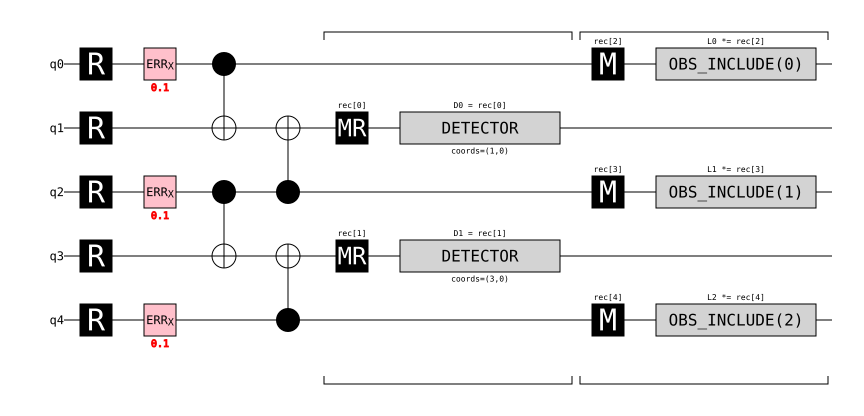

In [16]:
# e.g. 3-qubit rep code

circuit = stim.Circuit('''
    R 0 1 2 3 4

    TICK
    X_ERROR(0.1) 0 2 4

    TICK
    CX 0 1 2 3
    
    TICK
    CX 2 1 4 3
    
    TICK
    MR 1 3
    
    DETECTOR(1, 0) rec[-2]
    DETECTOR(3, 0) rec[-1]

    TICK
    M 0 2 4
    OBSERVABLE_INCLUDE(0) rec[-3]
    OBSERVABLE_INCLUDE(1) rec[-2]
    OBSERVABLE_INCLUDE(2) rec[-1]
''')

circuit.diagram('timeline-svg')

In [17]:
# generalized rep code

def repetition_code_circuit(n: int, p: float = 0.1) -> stim.Circuit:
    """
    Build an n-qubit repetition code circuit using a Stim string.

    Layout:
      data qubits:   0, 2, 4, ..., 2(n-1)
      ancilla qubits:1, 3, 5, ..., 2(n-2)+1

    Total qubits: 2n-1
    """

    # SOLUTION ===

    data_qubits = [q for q in range(0, 2*n - 1, 2)]
    ancilla_qubits = [q for q in range(1, 2*n - 1, 2)]

    circuit = stim.Circuit()

    circuit.append("R", range(2*n - 1))
    circuit.append("TICK")

    circuit.append("X_ERROR", data_qubits, p)
    circuit.append("TICK")

    # First CX round: data[i] -> ancilla[i]  (left neighbour)
    cx1 = []
    for i in range(n - 1):
        cx1 += [data_qubits[i], ancilla_qubits[i]]
    circuit.append("CX", cx1)
    circuit.append("TICK")

    # Second CX round: data[i+1] -> ancilla[i]  (right neighbour)
    cx2 = []
    for i in range(n - 1):
        cx2 += [data_qubits[i + 1], ancilla_qubits[i]]
    circuit.append("CX", cx2)
    circuit.append("TICK")

    # Measure-and-reset ancilla qubits
    circuit.append("MR", ancilla_qubits)

    # Detectors: ancilla[i] is the (i+1)-th measurement from the end
    num_ancilla = n - 1
    for i, aq in enumerate(ancilla_qubits):
        circuit.append("DETECTOR", [stim.target_rec(-(num_ancilla - i))], (aq, 0))

    circuit.append("TICK")

    # Final measurement of data qubits
    circuit.append("M", data_qubits)

    # Logical observables: data[i] is the (n-i)-th measurement from the end
    for i in range(n):
        circuit.append("OBSERVABLE_INCLUDE", [stim.target_rec(-(n - i))], i)

    return circuit

    # ===


def simulate_circuit(circuit, n, num_shots=100_000):
    """ 
    Simulate the circuit and return the results.

    Args:
        circuit: The circuit to simulate.
        n: The number of data qubits.

    Returns:
        results: {(data_bits, stabilizer_bits): counts}
    """

    # SOLUTION ===

    # compile_sampler() returns ALL raw measurements per shot:
    #   positions 0 .. n-2  -> ancilla MR (stabilizer bits)
    #   positions n-1 .. 2n-2 -> data M (data bits)
    sampler = circuit.compile_sampler()
    samples = sampler.sample(shots=num_shots)
    results = {}
    for sample in samples:
        stabilizer_bits = ''.join(str(int(b)) for b in sample[:n - 1])
        data_bits       = ''.join(str(int(b)) for b in sample[n - 1:])
        key = (data_bits, stabilizer_bits)
        results[key] = results.get(key, 0) + 1
    return results

    # ===

def logical_error_rate(
    results: dict[tuple[str, str], int],
    logical_prepared: int = 0,
) -> float:
    """
    Compute logical error rate using decode_repetition_code.

    Args:
        results: {(data_bits, stabilizer_bits): counts}
        logical_prepared: 0 or 1 logical state that was prepared.

    Returns:
        Logical error probability.
    """

    # SOLUTION ===
    total = sum(results.values())
    if total == 0:
        return 0.0
    error_count = 0
    for (data_bits, stabilizer_bits), count in results.items():
        decoded_logical_value = decode_repetition_code((data_bits, stabilizer_bits))
        if decoded_logical_value != logical_prepared:
            error_count += count
            
    return error_count / total
    # ===


def run_sim(n, p):
    circuit = repetition_code_circuit(n, p=p)
    results = simulate_circuit(circuit, n)
    return logical_error_rate(results, logical_prepared=0)


In [18]:
# Example
n = 3
p = 0.1
circuit = repetition_code_circuit(n, p=p)

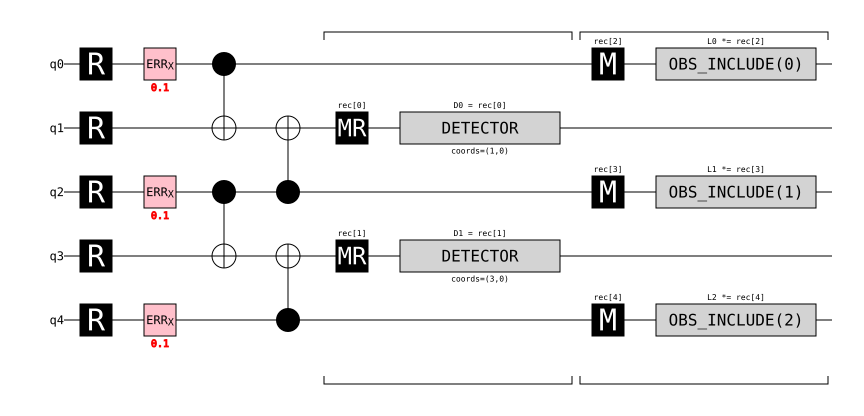

In [19]:
circuit.diagram('timeline-svg')

In [20]:
results = simulate_circuit(circuit, n)
results

{('000', '00'): 72811,
 ('001', '01'): 8250,
 ('010', '11'): 8130,
 ('100', '10'): 8017,
 ('110', '01'): 918,
 ('011', '10'): 894,
 ('101', '11'): 879,
 ('111', '00'): 101}

In [21]:
print(logical_error_rate(results, logical_prepared=0))

prob_two_error = 3 * (1-p) * p * p
prob_three_error = p * p * p
sim_logical_error_rate = prob_two_error + prob_three_error

print(sim_logical_error_rate)

0.02792
0.028000000000000004


In [ ]:
error_probabilities = np.logspace(-1, np.log10(0.5), 21)
distances = [3, 5, 7, 9]

# SOLUTION ===
# collect simulation data for varying distances and error_probabilities

data = {}
for i in distances:
    data[i] = []
    for p in error_probabilities:
        ler = run_sim(i, p)
        data[i].append(ler)
# ===

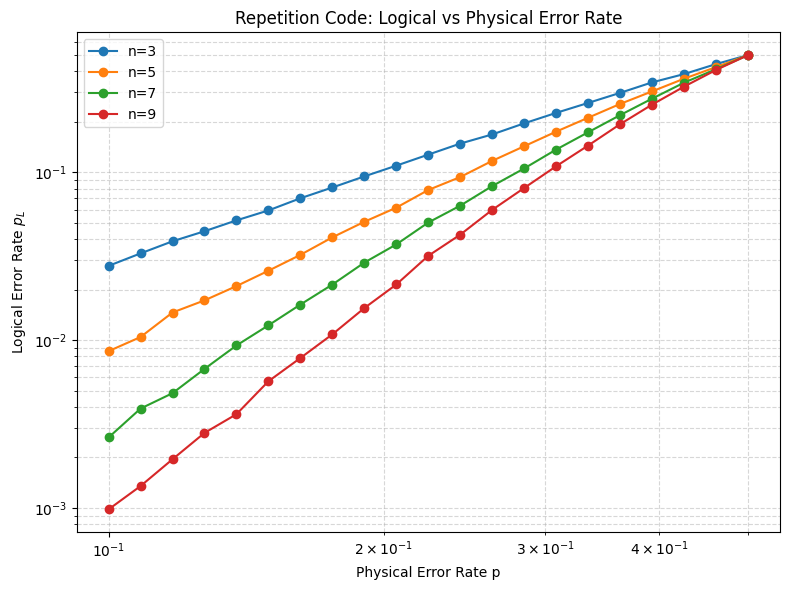

In [ ]:

# SOLUTION ===
# plot results

fig, ax = plt.subplots(figsize=(8, 6))

for d in distances:
    ax.loglog(error_probabilities, data[d], marker='o', label=f'n={d}')

ax.set_xlabel("Physical Error Rate p")
ax.set_ylabel("Logical Error Rate $p_L$")
ax.set_title("Repetition Code: Logical vs Physical Error Rate")
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ===


# 4 - Compare surface code vs cat-repetition code

In this section, we will benchmark the cat-repetition code against a conventional surface code built from unbiased qubits. While the surface code is designed to protect against general, symmetric noise, the cat-repetition code is optimized for a strongly biased error channel in which phase flips are exponentially suppressed and bit flips dominate. By comparing these two architectures under their respective noise models, we can directly evaluate the advantages of exploiting hardware bias. We will focus on resource efficiency, logical error rates, and scaling with system size to highlight when and why a bias-tailored code can outperform a more general-purpose quantum error correcting code.

Here is an especially useful resource for this section: 
[https://github.com/quantumlib/Stim/blob/main/doc/getting_started.ipynb](https://github.com/quantumlib/Stim/blob/main/doc/getting_started.ipynb)

Please feel free to adapt code from the above notebook. The point of the tasks in this section is to explore logical error rates and hardware resource overheads in different parameter regimes, not figure out syntax.

## Task 4.1 - cat-repetition code threshold

Since cat qubits can exponentially suppress phase-flip errors, the dominant remaining noise channel is bit flips on the encoded qubits. In this task, you will study how the logical error rate scales with the number of cat qubits used as data qubits in a repetition code, assuming each data qubit experiences a fixed bit-flip error rate.

[TODO, 2.5pts]: First, complete `generate_rep_code_bit_flips` to return a repetition-code memory circuit with distance `d`, `3d` rounds, and bit-flip noise applied as `X_ERROR(noise)` on the data qubits. You may use Stim’s built-in repetition-code memory generator rather than implementing the circuit from scratch.

In [ ]:
def generate_rep_code_bit_flips(d, noise):
    # SOLUTION ===
    circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=3*d,
    distance=d,
    before_measure_flip_probability=noise)
    # ===
    return circuit

We can then use this repetition code generation function to once again extract a threshold.

In [ ]:
tasks = [
    sinter.Task(
        circuit=generate_rep_code_bit_flips(d, noise),
        json_metadata={'d': d, 'p': noise},
    )
    for d in [3, 5, 7, 9]
    for noise in [0.05, 0.08, 0.1, 0.2, 0.3, 0.4, 0.5]
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=500,
)

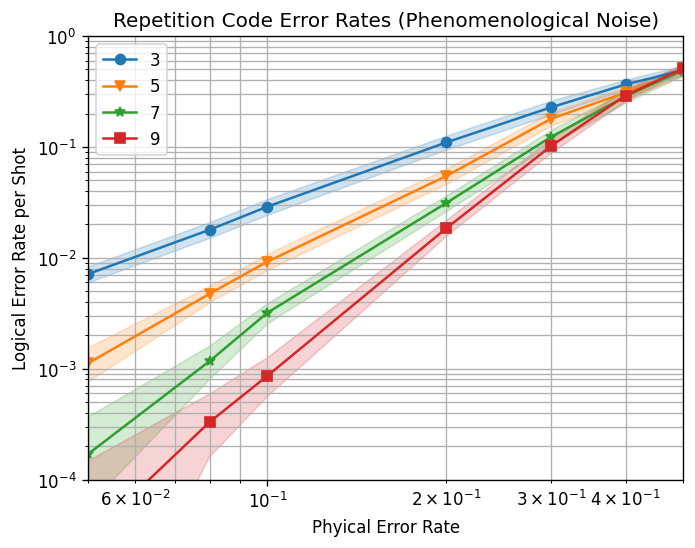

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
ax.set_ylim(1e-4, 1e-0)
ax.set_xlim(5e-2, 5e-1)
ax.loglog()
ax.set_title("Repetition Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

[TODO, 2.5pts]: Next, fix the physical bit-flip probability to $p_X = 0.01$. Assuming a cat-qubit noise bias of $10^8$, the corresponding phase-flip probability is $p_Z = 10^{-10}$. How many cat qubits are required in a repetition code to suppress the logical bit-flip probability below $10^{-10}$, so that it is comparable to the phase-flip level?

These parameter choices are loosely inspired by the following references, which provide a more detailed and rigorous analysis of error correction with cat qubits:
- [https://arxiv.org/abs/2302.06639](https://arxiv.org/abs/2302.06639)
- [https://arxiv.org/abs/2401.09541](https://arxiv.org/abs/2401.09541) 

Make a plot of logical error rate versus code distance $d$ for fixed $p_X = 0.01$. Note that the code distance $d$ is equal to the number of data qubits $n$ for the repetition code. Use `generate_rep_code_bit_flips`, which injects only bit flips, since phase flips are negligible in this regime.

Hint: extrapolate.


d=5: 115 errors / 10000000 shots = 1.15e-05
d=3: 2991 errors / 10000000 shots = 2.99e-04

Estimated code distance needed for p_L < 1e-10: d ≈ 12.2
Rounding up to nearest odd integer: d = 13


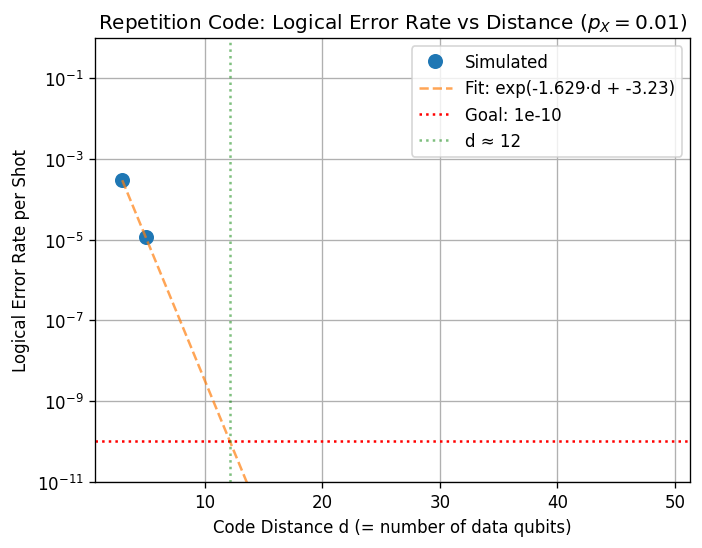

In [ ]:
bit_flip_prob = 0.01
noise_bias = 1e8
goal_logical_error_rate = bit_flip_prob/noise_bias
noise = 0.01


# SOLUTION ===
# Use small distances where errors are still observable, then extrapolate
distances = [3, 5, 7]
tasks = [
    sinter.Task(
        circuit=generate_rep_code_bit_flips(d, bit_flip_prob),
        json_metadata={'d': d, 'p': bit_flip_prob},
    )
    for d in distances
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,   # 10M shots to catch rare errors at larger d
    max_errors=5_000,
)

# Extract (distance, logical_error_rate) pairs
sim_distances = []
sim_error_rates = []
for stat in collected_stats:
    d = stat.json_metadata['d']
    if stat.errors > 0:
        sim_distances.append(d)
        sim_error_rates.append(stat.errors / stat.shots)
        print(f"d={d}: {stat.errors} errors / {stat.shots} shots = {stat.errors/stat.shots:.2e}")

sim_distances = np.array(sim_distances)
sim_error_rates = np.array(sim_error_rates)

# Fit log(p_L) = a * d + b  (exponential suppression)
coeffs = np.polyfit(sim_distances, np.log(sim_error_rates), 1)
a, b = coeffs

# Extrapolate: find d where p_L = goal
d_extrap = np.arange(3, 51, 2)
p_L_extrap = np.exp(a * d_extrap + b)

d_needed = (np.log(goal_logical_error_rate) - b) / a
print(f"\nEstimated code distance needed for p_L < {goal_logical_error_rate:.0e}: d ≈ {d_needed:.1f}")
print(f"Rounding up to nearest odd integer: d = {int(np.ceil(d_needed)) | 1}")

# Plot
fig, ax = plt.subplots(1, 1)
ax.semilogy(sim_distances, sim_error_rates, 'o', label='Simulated', markersize=8)
ax.semilogy(d_extrap, p_L_extrap, '--', label=f'Fit: exp({a:.3f}·d + {b:.2f})', alpha=0.7)
ax.axhline(goal_logical_error_rate, color='red', linestyle=':', label=f'Goal: {goal_logical_error_rate:.0e}')
ax.axvline(d_needed, color='green', linestyle=':', alpha=0.5, label=f'd ≈ {d_needed:.0f}')
ax.set_xlabel("Code Distance d (= number of data qubits)")
ax.set_ylabel("Logical Error Rate per Shot")
ax.set_title(f"Repetition Code: Logical Error Rate vs Distance $(p_X = {bit_flip_prob})$")
ax.set_ylim(goal_logical_error_rate / 10, 1)
ax.grid(which='both')
ax.legend()
fig.set_dpi(120)

# ===


## 4.2 - surface code benchmarks

The surface code can be viewed as a two-dimensional generalization of the repetition code that protects against both bit-flip and phase-flip errors. For this reason, many groups are pursuing surface-code architectures built from unbiased qubits (such as transmons) to suppress both types of logical errors simultaneously.

Next, we will generate an analogous plot of logical error rate versus the number of data qubits for a fixed physical depolarizing error probability of 0.001 using the surface code. From this, we will estimate how many qubits are required to reach a logical error rate of ($10^{-10}$), enabling a direct comparison with the cat-repetition results.


### 4.2.1 - surface code threshold

[TODO, 2.5pts]: First, complete `generate_surface_code_depolarizing_noise` to return a surface-code memory circuit with distance `d`, `3d` rounds, and depolarizing noise applied on data qubits. You may use Stim’s built-in surface-code memory generator and flags rather than implementing the circuit from scratch.

In [ ]:
def generate_surface_code_depolarizing_noise(d, noise):
    # SOLUTION ===
    circuit = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=d * 3,
        distance=d,
        after_clifford_depolarization=noise,
        after_reset_flip_probability=noise,
        before_measure_flip_probability=noise,
        before_round_data_depolarization=noise,
    )
    
    # ===
    return circuit

Then, we can use stim tooling to find the threshold for the surface code.

In [ ]:
import os

surface_code_tasks = [
    sinter.Task(
        circuit = generate_surface_code_depolarizing_noise(d, noise),
        json_metadata={'d': d, 'r': d * 3, 'p': noise},
    )
    for d in [3, 5, 7]
    for noise in [0.008, 0.009, 0.01, 0.011, 0.012]
]

collected_surface_code_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=os.cpu_count(),
    tasks=surface_code_tasks,
    decoders=['pymatching'],
    max_shots=1_000_000,
    max_errors=5_000,
    print_progress=True,
)

Starting 8 workers...
15 tasks left:
  workers    decoder eta shots_left errors_left json_metadata   
        1 pymatching   ?    1000000        5000 d=3,r=9,p=0.008 
        1 pymatching   ?    1000000        5000 d=3,r=9,p=0.009 
        1 pymatching   ?    1000000        5000 d=3,r=9,p=0.01  
        1 pymatching   ?    1000000        5000 d=3,r=9,p=0.011 
        1 pymatching   ?    1000000        5000 d=3,r=9,p=0.012 
        1 pymatching <1m     999727        4960 d=5,r=15,p=0.008
        1 pymatching   ?    1000000        5000 d=5,r=15,p=0.009
        1 pymatching   ?    1000000        5000 d=5,r=15,p=0.01 
        0 pymatching ?·∞    1000000        5000 d=5,r=15,p=0.011
        0 pymatching ?·∞    1000000        5000 d=5,r=15,p=0.012
        0 pymatching ?·∞    1000000        5000 d=7,r=21,p=0.008
        0 pymatching ?·∞    1000000        5000 d=7,r=21,p=0.009
        0 pymatching ?·∞    1000000        5000 d=7,r=21,p=0.01 
        0 pymatching ?·∞    1000000        5000 d=7,r

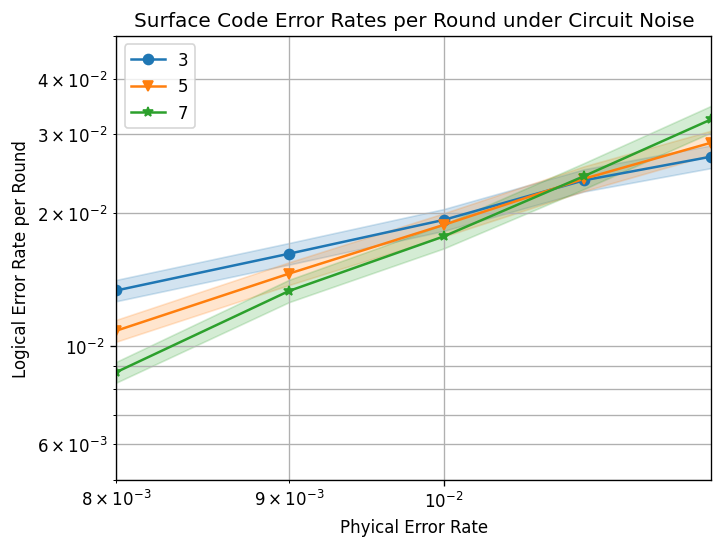

In [ ]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_surface_code_stats,
    x_func=lambda stat: stat.json_metadata['p'],
    group_func=lambda stat: stat.json_metadata['d'],
    failure_units_per_shot_func=lambda stat: stat.json_metadata['r'],
)
ax.set_ylim(5e-3, 5e-2)
ax.set_xlim(0.008, 0.012)
ax.loglog()
ax.set_title("Surface Code Error Rates per Round under Circuit Noise")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Round")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger

### 4.2.2 - estimate # of qubits for fault-tolerance

[TODO, 2.0pts]: Next, fix the depolarizing noise probability to $p = 0.001$, inspired by SOTA performance in transmon-based surface codes. As we did for the cat-repetition code, make a plot of logical error rate versus code distance $d$, which is equal to $\sqrt{n}$ for the square surface code, where $n$ is the number of data qubits. Use your `generate_surface_code_depolarizing_noise` function. The lower ylim of your plot should be `goal_logical_error_rate`. 

Hint: extrapolate.

d=3: 5003 errors / 2322705 shots = 2.15e-03
d=5: 4361 errors / 10000000 shots = 4.36e-04
d=7: 554 errors / 10000000 shots = 5.54e-05

Estimated code distance needed for p_L < 1e-10: d ≈ 21.5
Rounding up to nearest odd integer: d = 23


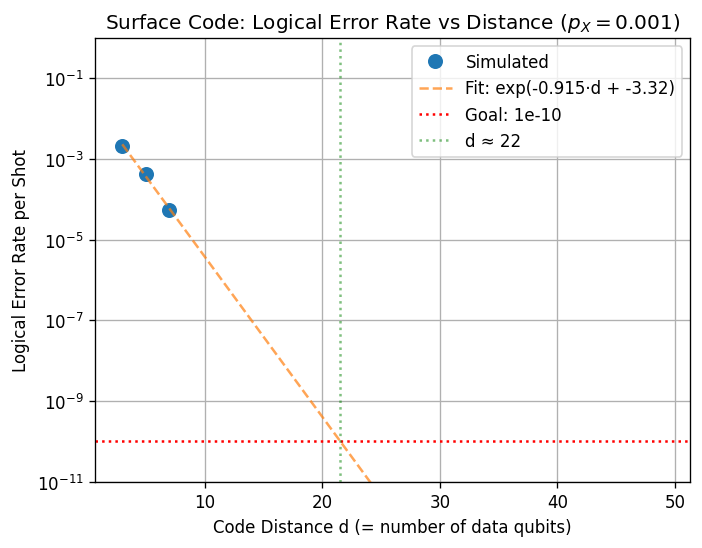

In [ ]:
noise = 1e-3
goal_logical_error_rate = 1e-10

# SOLUTION ===

# Use small distances where errors are still observable, then extrapolate
distances = [3, 5, 7]
tasks = [
    sinter.Task(
        circuit=generate_surface_code_depolarizing_noise(d, noise),
        json_metadata={'d': d, 'p': noise},
    )
    for d in distances
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,   # 10M shots to catch rare errors at larger d
    max_errors=5_000,
)

# Extract (distance, logical_error_rate) pairs
sim_distances = []
sim_error_rates = []
for stat in collected_stats:
    d = stat.json_metadata['d']
    if stat.errors > 0:
        sim_distances.append(d)
        sim_error_rates.append(stat.errors / stat.shots)
        print(f"d={d}: {stat.errors} errors / {stat.shots} shots = {stat.errors/stat.shots:.2e}")

sim_distances = np.array(sim_distances)
sim_error_rates = np.array(sim_error_rates)

# Fit log(p_L) = a * d + b  (exponential suppression)
coeffs = np.polyfit(sim_distances, np.log(sim_error_rates), 1)
a, b = coeffs

# Extrapolate: find d where p_L = goal
d_extrap = np.arange(3, 51, 2)
p_L_extrap = np.exp(a * d_extrap + b)

d_needed = (np.log(goal_logical_error_rate) - b) / a
print(f"\nEstimated code distance needed for p_L < {goal_logical_error_rate:.0e}: d ≈ {d_needed:.1f}")
print(f"Rounding up to nearest odd integer: d = {int(np.ceil(d_needed)) | 1}")

# Plot
fig, ax = plt.subplots(1, 1)
ax.semilogy(sim_distances, sim_error_rates, 'o', label='Simulated', markersize=8)
ax.semilogy(d_extrap, p_L_extrap, '--', label=f'Fit: exp({a:.3f}·d + {b:.2f})', alpha=0.7)
ax.axhline(goal_logical_error_rate, color='red', linestyle=':', label=f'Goal: {goal_logical_error_rate:.0e}')
ax.axvline(d_needed, color='green', linestyle=':', alpha=0.5, label=f'd ≈ {d_needed:.0f}')
ax.set_xlabel("Code Distance d (= number of data qubits)")
ax.set_ylabel("Logical Error Rate per Shot")
ax.set_title(f"Surface Code: Logical Error Rate vs Distance $(p_X = {noise})$")
ax.set_ylim(goal_logical_error_rate / 10, 1)
ax.grid(which='both')
ax.legend()
fig.set_dpi(120)

# ===

d   p      pL_3.2(manuale)   pL_4.1(stim)    |diff|      diff_rel
3   0.10     2.7730e-02        2.7660e-02    7.00e-05      0.25%
3   0.20     1.0380e-01        1.0426e-01    4.59e-04      0.44%
3   0.30     2.1569e-01        2.1193e-01    3.76e-03      1.75%
3   0.40     3.5346e-01        3.4970e-01    3.76e-03      1.06%
3   0.50     5.0087e-01        5.1041e-01    9.54e-03      1.91%
5   0.10     8.6000e-03        8.6000e-03    3.47e-18      0.00%
5   0.20     5.7365e-02        5.6766e-02    5.99e-04      1.04%
5   0.30     1.6376e-01        1.6687e-01    3.11e-03      1.90%
5   0.40     3.1693e-01        3.2258e-01    5.65e-03      1.78%
5   0.50     5.0071e-01        5.0126e-01    5.49e-04      0.11%
7   0.10     2.6300e-03        2.7200e-03    9.00e-05      3.42%
7   0.20     3.3975e-02        3.4660e-02    6.85e-04      2.02%
7   0.30     1.2575e-01        1.2433e-01    1.42e-03      1.13%
7   0.40     2.9030e-01        2.8343e-01    6.87e-03      2.37%
7   0.50     5.0014e-01 

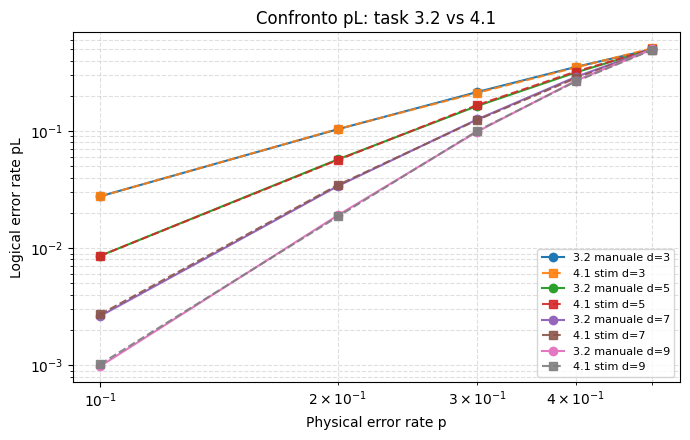

In [ ]:
# task 3.2 vs task 4.1 comparison

compare_distances = [3, 5, 7, 9]
compare_ps = [0.1, 0.2, 0.3, 0.4, 0.5]

if 'data' not in globals() or 'error_probabilities' not in globals():
    error_probabilities = np.logspace(-1, np.log10(0.5), 21)
    data = {d: [run_sim(d, p) for p in error_probabilities] for d in compare_distances}

manual_map = {}
for d in compare_distances:
    y = np.array(data[d], dtype=float)
    x = np.array(error_probabilities, dtype=float)
    for p in compare_ps:
        manual_map[(d, p)] = float(np.interp(p, x, y))

compare_tasks = [
    sinter.Task(
        circuit=generate_rep_code_bit_flips(d, p),
        json_metadata={'d': d, 'p': p},
    )
    for d in compare_distances
    for p in compare_ps
]

compare_stats = sinter.collect(
    num_workers=4,
    tasks=compare_tasks,
    decoders=['pymatching'],
    max_shots=50_000,
    max_errors=2_000,
)

stim_map = {}
for st in compare_stats:
    d = int(st.json_metadata['d'])
    p = float(st.json_metadata['p'])
    stim_map[(d, p)] = st.errors / st.shots if st.shots > 0 else np.nan

rows = []
for d in compare_distances:
    for p in compare_ps:
        m = manual_map[(d, p)]
        s = stim_map[(d, p)]
        abs_diff = abs(m - s)
        rel_diff = abs_diff / m if m > 0 else np.nan
        rows.append((d, p, m, s, abs_diff, rel_diff))

print('d   p      pL_3.2(manuale)   pL_4.1(stim)    |diff|      diff_rel')
for d, p, m, s, ad, rd in rows:
    print(f'{d:<2}  {p:0.2f}   {m:>12.4e}      {s:>12.4e}   {ad:>9.2e}   {rd:>8.2%}')

mean_abs = float(np.nanmean([r[4] for r in rows]))
mean_rel = float(np.nanmean([r[5] for r in rows]))
print(f'\nDifferenza media assoluta: {mean_abs:.3e}')
print(f'Differenza media relativa: {mean_rel:.2%}')

fig, ax = plt.subplots(figsize=(7, 4.5))

for d in compare_distances:
    p_vals = np.array(compare_ps)
    y_manual = np.array([manual_map[(d, p)] for p in p_vals])
    y_stim = np.array([stim_map[(d, p)] for p in p_vals])

    ax.loglog(p_vals, y_manual, 'o-', label=f'3.2 manuale d={d}')
    ax.loglog(p_vals, y_stim, 's--', label=f'4.1 stim d={d}', alpha=0.9)

ax.set_title('Confronto pL: task 3.2 vs 4.1')
ax.set_xlabel('Physical error rate p')
ax.set_ylabel('Logical error rate pL')
ax.grid(True, which='both', ls='--', alpha=0.4)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



[TODO, 0.5pts]: Finally, compare the performance of the cat-repetition code to the surface code. In particular, comment on the resource requirements and potential challenges of both approaches.

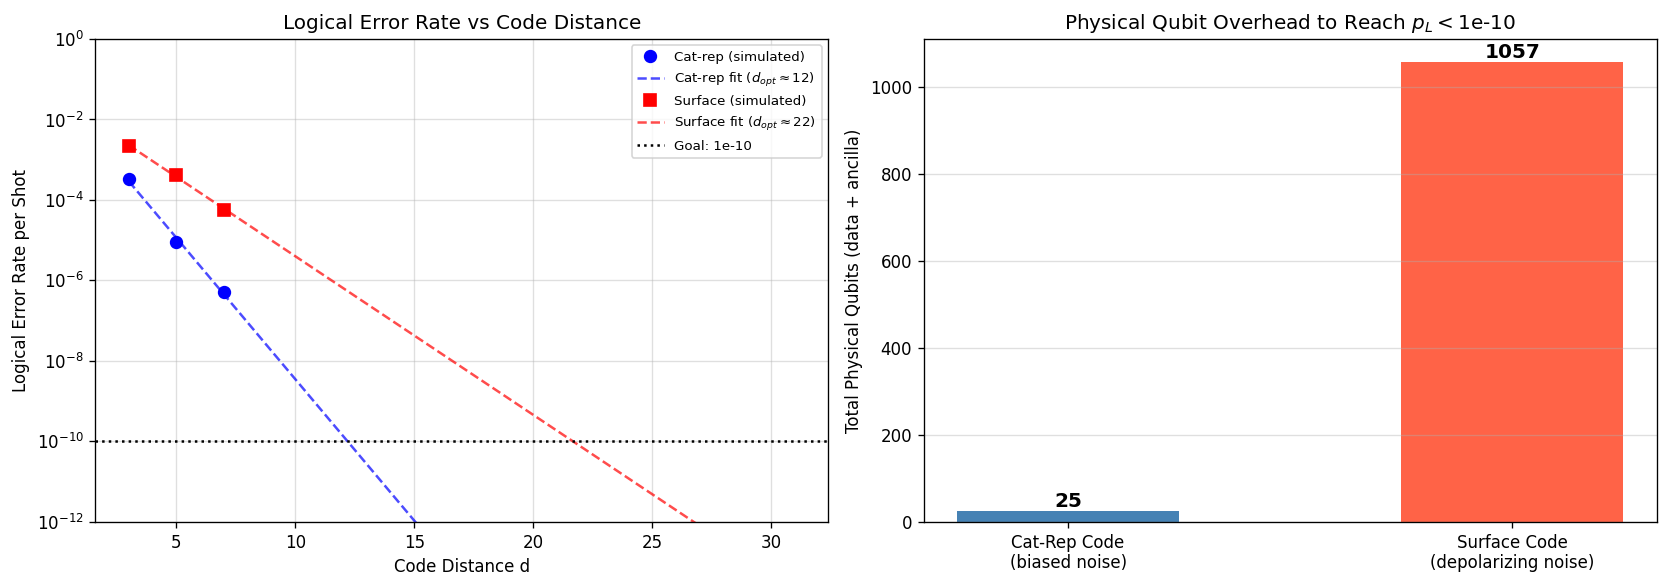

Metric                                    Cat-Rep  Surface
Physical error rate                      0.01 (X)    0.001
Code distance needed                           13       23
Data qubits                                    13      529
Ancilla qubits                                 12      528
Total physical qubits                          25     1057
Encoding rate k/n                          0.0769   0.0019
Max connectivity (max qubit degree)        2 (1D)   4 (2D)

Key observations:
  - Repetition code requires fewer physical qubits than the surface code
    to reach the same logical error rate target.
  - Repetition code needs only nearest-neighbor 1D connectivity, which is
    simpler to engineer than the 2D grid needed for the surface code.
  - The surface code protects against both X and Z errors natively,
    whereas the cat-rep code relies on the hardware (cat qubit bias)
    to suppress Z errors: while the code is simpler and scales better, it requires custom hardware.
  - Th

In [ ]:
# Compare cat-repetition code vs surface code resource requirements

# Parameters
cat_rep_p_X = 0.01
noise_bias = 1e8
cat_rep_p_Z = cat_rep_p_X / noise_bias
surface_p = 1e-3
goal_logical_error_rate = 1e-10

# --- Cat-repetition code ---
# Fit from Task 4.1 simulation data (rep code, p_X=0.01)
rep_tasks = [
    sinter.Task(
        circuit=generate_rep_code_bit_flips(d, cat_rep_p_X),
        json_metadata={'d': d, 'p': cat_rep_p_X},
    )
    for d in [3, 5, 7, 9]
]
rep_stats = sinter.collect(
    num_workers=4,
    tasks=rep_tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=200,
)
rep_distances, rep_error_rates = [], []
for stat in rep_stats:
    if stat.errors > 0:
        rep_distances.append(stat.json_metadata['d'])
        rep_error_rates.append(stat.errors / stat.shots)

rep_distances = np.array(rep_distances)
rep_error_rates = np.array(rep_error_rates)
rep_coeffs = np.polyfit(rep_distances, np.log(rep_error_rates), 1)
rep_a, rep_b = rep_coeffs

rep_d_needed = (np.log(goal_logical_error_rate) - rep_b) / rep_a
rep_d_needed_int = int(np.ceil(rep_d_needed)) | 1
rep_n_data = rep_d_needed_int                  # data qubits = d for rep code
rep_n_ancilla = rep_d_needed_int - 1           # ancilla qubits = d-1
rep_n_total = rep_n_data + rep_n_ancilla       # total physical qubits

# --- Surface code ---
surf_tasks = [
    sinter.Task(
        circuit=generate_surface_code_depolarizing_noise(d, surface_p),
        json_metadata={'d': d, 'p': surface_p},
    )
    for d in [3, 5, 7]
]
surf_stats = sinter.collect(
    num_workers=4,
    tasks=surf_tasks,
    decoders=['pymatching'],
    max_shots=10_000_000,
    max_errors=200,
)
surf_distances, surf_error_rates = [], []
for stat in surf_stats:
    if stat.errors > 0:
        surf_distances.append(stat.json_metadata['d'])
        surf_error_rates.append(stat.errors / stat.shots)

surf_distances = np.array(surf_distances)
surf_error_rates = np.array(surf_error_rates)
surf_coeffs = np.polyfit(surf_distances, np.log(surf_error_rates), 1)
surf_a, surf_b = surf_coeffs

surf_d_needed = (np.log(goal_logical_error_rate) - surf_b) / surf_a
surf_d_needed_int = int(np.ceil(surf_d_needed)) | 1
surf_n_data = surf_d_needed_int ** 2           # data qubits = d^2
surf_n_ancilla = (surf_d_needed_int**2 - 1)   # ancilla qubits ≈ d^2-1
surf_n_total = surf_n_data + surf_n_ancilla    # total physical qubits

# --- Plot comparison ---
d_range_rep = np.arange(3, max(rep_d_needed_int + 10, 30), 2)
d_range_surf = np.arange(3, surf_d_needed_int + 10, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: logical error rate vs distance
ax = axes[0]
ax.semilogy(rep_distances, rep_error_rates, 'bo', label='Cat-rep (simulated)', markersize=7)
ax.semilogy(d_range_rep, np.exp(rep_a * d_range_rep + rep_b), 'b--',
            label=f'Cat-rep fit ($d_{"{opt}"}\\approx{rep_d_needed:.0f}$)', alpha=0.7)
ax.semilogy(surf_distances, surf_error_rates, 'rs', label='Surface (simulated)', markersize=7)
ax.semilogy(d_range_surf, np.exp(surf_a * d_range_surf + surf_b), 'r--',
            label=f'Surface fit ($d_{"{opt}"}\\approx{surf_d_needed:.0f}$)', alpha=0.7)
ax.axhline(goal_logical_error_rate, color='k', linestyle=':', label=f'Goal: {goal_logical_error_rate:.0e}')
ax.set_xlabel("Code Distance d")
ax.set_ylabel("Logical Error Rate per Shot")
ax.set_title("Logical Error Rate vs Code Distance")
ax.set_ylim(goal_logical_error_rate / 100, 1)
ax.grid(which='both', alpha=0.4)
ax.legend(fontsize=8)

# Right: bar chart of total physical qubits
ax2 = axes[1]
codes = ['Cat-Rep Code\n(biased noise)', 'Surface Code\n(depolarizing noise)']
totals = [rep_n_total, surf_n_total]
colors = ['steelblue', 'tomato']
bars = ax2.bar(codes, totals, color=colors, width=0.5)
for bar, val in zip(bars, totals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel("Total Physical Qubits (data + ancilla)")
ax2.set_title(f"Physical Qubit Overhead to Reach $p_L < ${goal_logical_error_rate:.0e}")
ax2.grid(axis='y', alpha=0.4)

fig.tight_layout()
fig.set_dpi(120)
plt.show()

# --- Summary ---
print("=" * 60)
print(f"{'Metric':<40} {'Cat-Rep':>8} {'Surface':>8}")
print("=" * 60)
print(f"{'Physical error rate':<40} {'0.01 (X)':>8} {'0.001':>8}")
print(f"{'Code distance needed':<40} {rep_d_needed_int:>8} {surf_d_needed_int:>8}")
print(f"{'Data qubits':<40} {rep_n_data:>8} {surf_n_data:>8}")
print(f"{'Ancilla qubits':<40} {rep_n_ancilla:>8} {surf_n_ancilla:>8}")
print(f"{'Total physical qubits':<40} {rep_n_total:>8} {surf_n_total:>8}")
print(f"{'Encoding rate k/n':<40} {1/rep_n_data:>8.4f} {1/surf_n_data:>8.4f}")
print(f"{'Max connectivity (max qubit degree)':<40} {'2 (1D)':>8} {'4 (2D)':>8}")
print("=" * 60)
print("""
Key observations:
  - Repetition code requires fewer physical qubits than the surface code
    to reach the same logical error rate target.
  - Repetition code needs only nearest-neighbor 1D connectivity, which is
    simpler to engineer than the 2D grid needed for the surface code.
  - The surface code protects against both X and Z errors natively,
    whereas the cat-rep code relies on the hardware (cat qubit bias)
    to suppress Z errors: while the code is simpler and scales better, it requires custom hardware.
  - The encoding rate k/n of the repetition code is low (1/n), but the
    reduced qubit count more than compensates in practice.
  - Operating cat qubits at large photon numbers to maintain high bias
    adds experimental complexity (longer gate times, higher ancilla costs).
""")

# 5 - Quantum error correction inspired by classical codes

## Core Task 5.1 - Explore QEC codes inspired by classical codes

[TODO, 70pts]:

Classical error correcting codes provide a natural and powerful pathway to constructing quantum codes by directly translating classical parity checks into quantum stabilizer measurements. In particular, any linear classical code can be mapped to a quantum code that detects and corrects **bit flip (X) errors** by promoting each classical parity check into a multi-qubit ( Z )-type stabilizer. In this construction, classical codewords become logical quantum states, and the syndrome extraction process is identical in spirit to classical decoding. This approach is especially well suited for hardware with **strong noise bias**, where one error channel dominates. In our case, biased cat qubits exponentially suppress phase flip errors, leaving bit flips as the primary failure mode. As a result, we can focus entirely on X-error correction, allowing us to use a much wider and more efficient family of classical codes than would be possible for fully general quantum noise.

The final and core challenge is to choose any classical error correcting code (or family of codes), translate it into its quantum counterpart, and benchmark it against the repetition code that you already implemented. You will simulate the resulting quantum code in **Stim**, extract syndromes, perform decoding, and compare key performance metrics such as logical error rate versus number of physical qubits at a fixed physical error rate, encoding efficiency ( k/n ), the effective distance of the code and required hardware connectivity (i.e. what two-qubit gates are needed). This exploration will show how classical coding theory can be directly leveraged to design quantum codes that outperform simple repetition strategies when the noise is strongly biased.

*Optionally*, only if time permits, you may wish to demonstrate a universal, fault-tolerant set of logical gates for your code, starting with the Clifford group and extending to non-Clifford gates.


Please refer to `./2-classical-to-quantum-codes.ipynb` for a step-by-step introduction to translating a classical code into a quantum bit-flip–correcting code, along with a curated (but not exhaustive) list of classical code families to use as inspiration. You should consider this notebook required reading for the core task in this challenge.

This is an open-ended challenge, judged by the criteria specified in the `README.md` doc. 

## Golay

In [ ]:
from golay23 import *

G shape: (12, 23)
H shape: (11, 23)
rank(G): 12
Syndromes in table: 2048 (expected 2048)


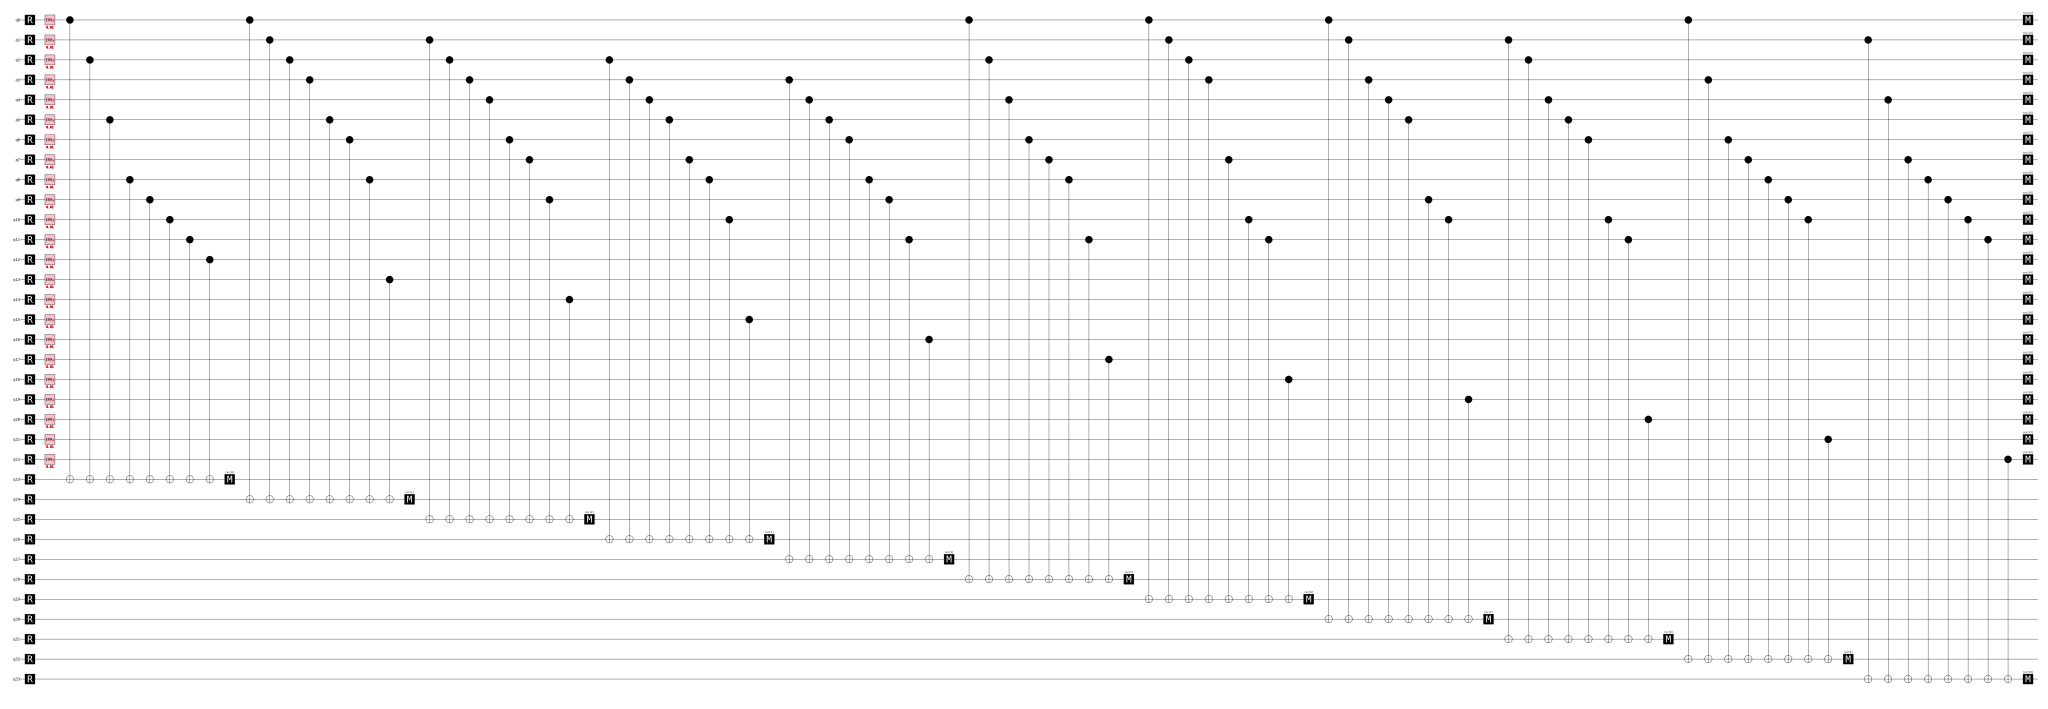

In [35]:
# Print quantum Golay circuit
p_demo = 0.01
c_qgolay = golay23_quantum_x_memory_circuit(p_demo)

c_qgolay.diagram('timeline-svg')

         p    quantum_sim         theory
------------------------------------------
  5.00e-03      6.000e-06      5.129e-06
  9.10e-03      5.700e-05      5.294e-05
  1.66e-02      5.230e-04      5.190e-04
  3.02e-02      4.658e-03      4.633e-03
  5.49e-02      3.490e-02      3.487e-02
  1.00e-01      1.925e-01      1.927e-01


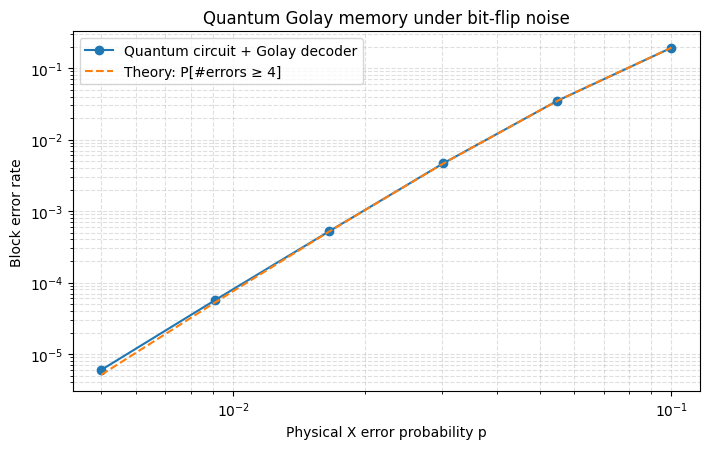

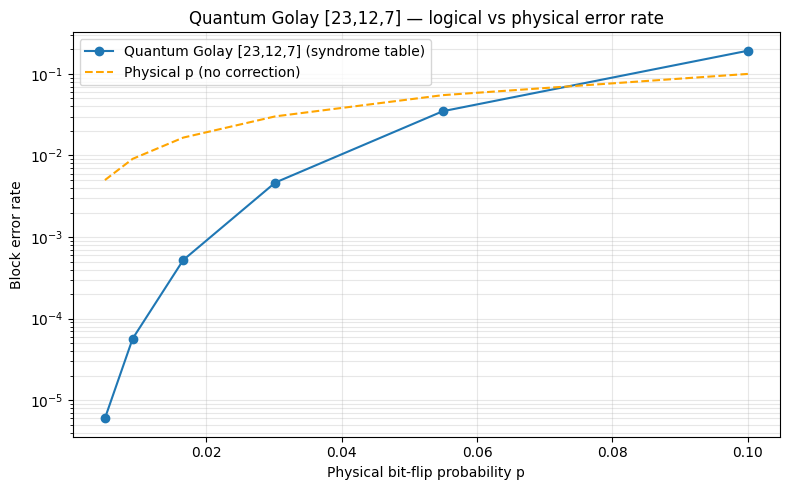

In [36]:
# --- Single simulation run ---
ps_q = np.logspace(np.log10(5e-3), -1, 6)
shots = 2_000_000

quantum_bler = []
theory_bler = []

print(f"{'p':>10s}   {'quantum_sim':>12s}   {'theory':>12s}")
print("-" * 42)
for p in ps_q:
    q_ber = golay23_quantum_block_error_rate(float(p), shots=shots)
    t_ber = golay23_theory_block_fail(float(p))
    quantum_bler.append(q_ber)
    theory_bler.append(t_ber)
    print(f"{p:10.2e}   {q_ber:12.3e}   {t_ber:12.3e}")

# --- Plot 1: Quantum sim vs Theory ---
fig1, ax1 = plt.subplots(figsize=(7.2, 4.6))
ax1.loglog(ps_q, quantum_bler, 'o-', label='Quantum circuit + Golay decoder')
ax1.loglog(ps_q, theory_bler, '--', label='Theory: P[#errors ≥ 4]')
ax1.set_xlabel('Physical X error probability p')
ax1.set_ylabel('Block error rate')
ax1.set_title('Quantum Golay memory under bit-flip noise')
ax1.grid(True, which='both', ls='--', alpha=0.4)
ax1.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Logical vs Physical (with reference line) ---
fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.semilogy(ps_q, [max(x, 1e-12) for x in quantum_bler], 'o-', label='Quantum Golay [23,12,7] (syndrome table)')
ax2.semilogy(ps_q, ps_q, '--', color='orange', label='Physical p (no correction)')
ax2.set_xlabel('Physical bit-flip probability p')
ax2.set_ylabel('Block error rate')
ax2.set_title('Quantum Golay [23,12,7] — logical vs physical error rate')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

### Expected results

The theoretical block error rate for the Golay $[23,12,7]$ code under a binary symmetric channel with bit-flip probability $p$ is the probability that more than $t = 3$ errors occur in a block of 23 bits:

$$P_{\text{block}} = 1 - \sum_{k=0}^{3} \binom{23}{k}\, p^k\, (1-p)^{23-k}$$

This follows from the fact that the Golay code has minimum distance $d = 7$ and can therefore correct up to $t = \lfloor (d-1)/2 \rfloor = 3$ errors per codeword.

**Reference:** Raymond Hill, *A First Course in Coding Theory*, Oxford University Press, 1986.

## Golay24

In [37]:
from golay24 import *

H shape: (12, 24)
HH^T mod 2 == 0 ? True
Correction table size: 4096 (expected 4096)


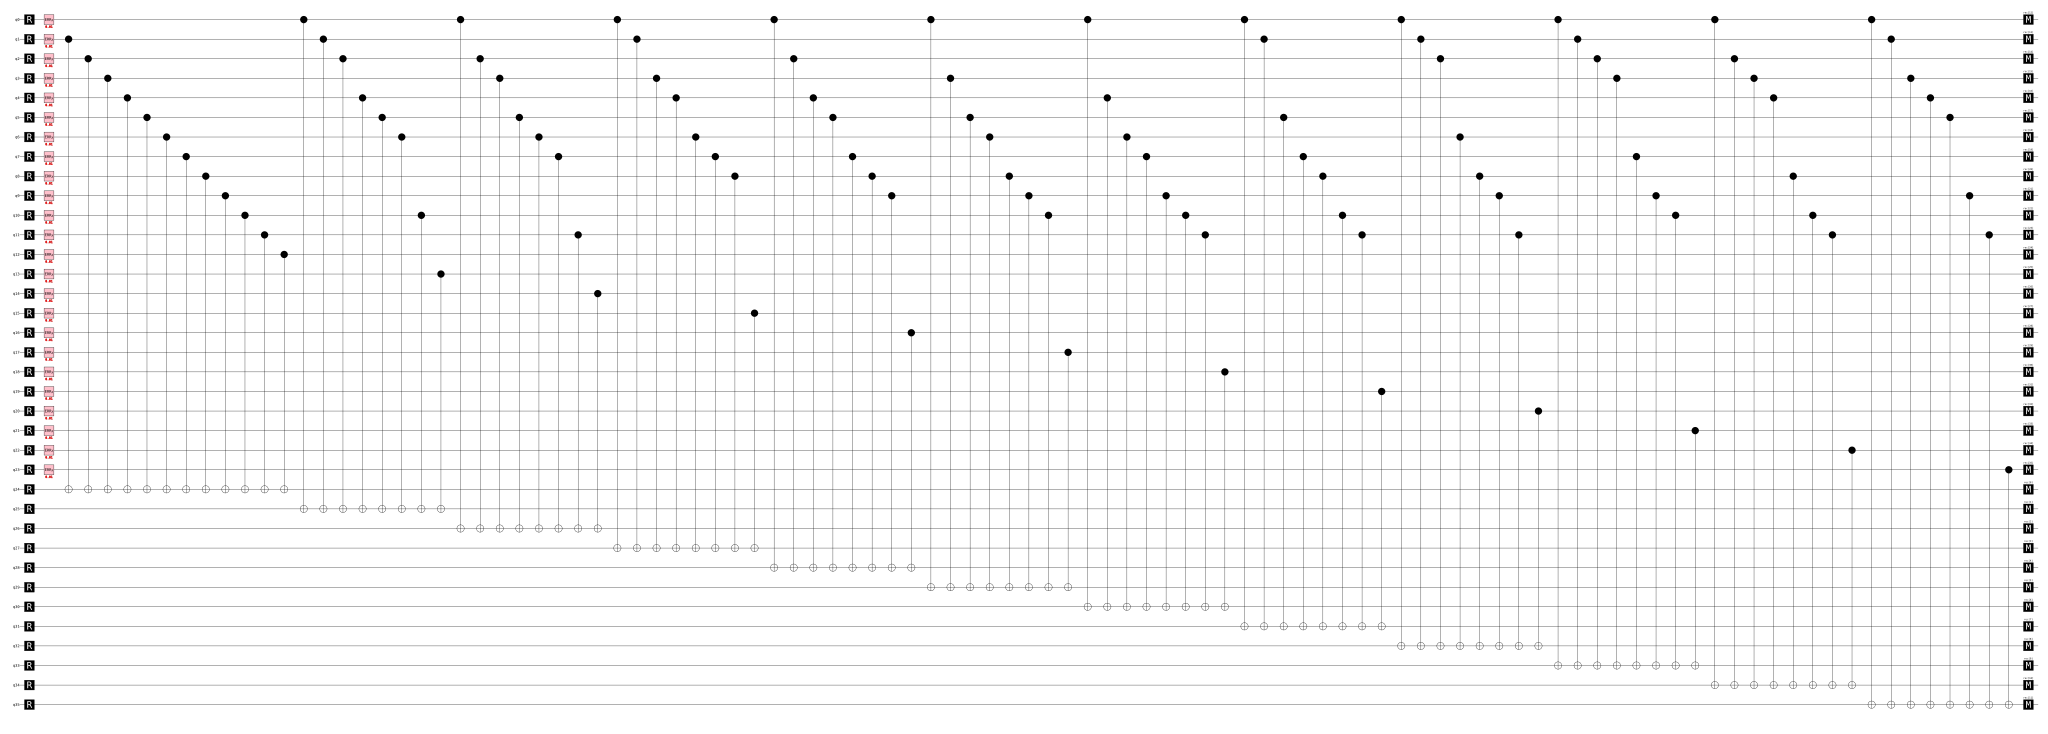

In [38]:
p_demo = 0.01
circuito_demo = golay24_x_memory_circuit(H, p_demo)

circuito_demo.diagram('timeline-svg')

R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
X_ERROR(0.01) 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
CX 1 24 2 24 3 24 4 24 5 24 6 24 7 24 8 24 9 24 10 24 11 24 12 24 0 25 1 25 2 25 4 25 5 25 6 25 10 25 13 25 0 26 2 26 3 26 5 26 6 26 7 26 11 26 14 26 0 27 1 27 3 27 4 27 6 27 7 27 8 27 15 27 0 28 2 28 4 28 5 28 7 28 8 28 9 28 16 28 0 29 3 29 5 29 6 29 8 29 9 29 10 29 17 29 0 30 4 30 6 30 7 30 9 30 10 30 11 30 18 30 0 31 1 31 5 31 7 31 8 31 10 31 11 31 19 31 0 32 1 32 2 32 6 32 8 32 9 32 11 32 20 32 0 33 1 33 2 33 3 33 7 33 9 33 10 33 21 33 0 34 2 34 3 34 4 34 8 34 10 34 11 34 22 34 0 35 1 35 3 35 4 35 5 35 9 35 11 35 23 35
M 24 25 26 27 28 29 30 31 32 33 34 35 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
p=0.001 -> block error rate = 0.000000e+00
p=0.005 -> block error rate = 8.000000e-06
p=0.010 -> block error rate = 9.400000e-05
p=0.020 -> block error rate = 9.810000e-04
p=0.050 -> block error 

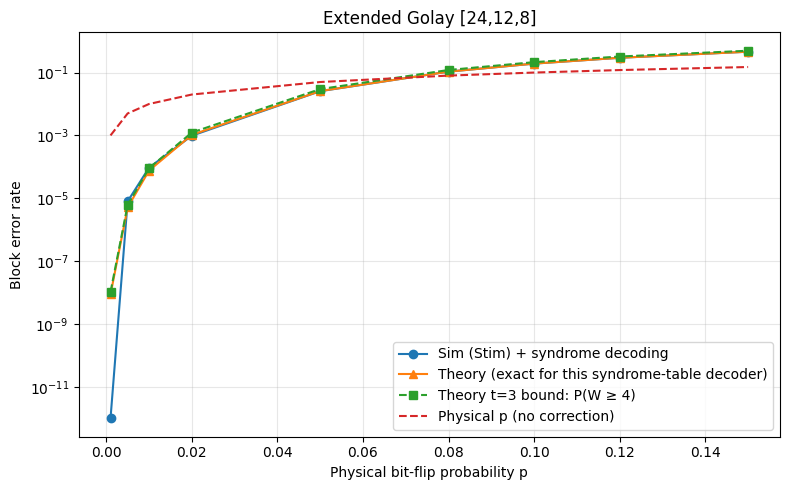

In [39]:
# --- Parameters ---
import math

p_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15]
shots = 1_000_000

# --- Print an example circuit (p=0.01) ---
c_demo = golay24_x_memory_circuit(H, p=0.01)
print(c_demo)

# --- Run simulation ---
bers = []
for i, p in enumerate(p_values):
    ber = simulate_golay24_quantum(H, corr_table, p, shots, seed=12345 + i)
    bers.append(ber)
    print(f"p={p:.3f} -> block error rate = {ber:.6e}")

# --- Theory curves ---
# 1) Standard bounded-distance line (guaranteed correction up to 3 errors)
theory_t3 = [golay24_theory_block_fail_t3(p) for p in p_values]

# 2) Exact line for this specific syndrome-table decoder
theory_decoder = [golay24_theory_block_fail_for_table(p, corr_table) for p in p_values]

# Quick diagnostic: fraction of weight-4 patterns that this table decodes exactly
leader_w = ((corr_table[:, None] >> np.arange(24, dtype=np.uint32)) & 1).sum(axis=1)
num_w4_leaders = int(np.sum(leader_w == 4))
print(
    f"Weight-4 patterns decoded exactly by this table: "
    f"{num_w4_leaders}/{math.comb(24,4)} = {num_w4_leaders / math.comb(24,4):.2%}"
)

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.semilogy(p_values, [max(x, 1e-12) for x in bers], 'o-', label='Sim (Stim) + syndrome decoding')
plt.semilogy(
    p_values,
    [max(x, 1e-12) for x in theory_decoder],
    '^-',
    label='Theory (exact for this syndrome-table decoder)'
)
plt.semilogy(
    p_values,
    [max(x, 1e-12) for x in theory_t3],
    's--',
    label='Theory t=3 bound: P(W ≥ 4)'
)
plt.semilogy(p_values, p_values, '--', label='Physical p (no correction)')
plt.xlabel('Physical bit-flip probability p')
plt.ylabel('Block error rate')
plt.title('Extended Golay [24,12,8]')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



p=1.000e-03 -> L1=0.000e+00, L2=0.000e+00, L3=0.000e+00
p=5.000e-03 -> L1=6.667e-06, L2=0.000e+00, L3=0.000e+00
p=1.000e-02 -> L1=9.000e-05, L2=0.000e+00, L3=0.000e+00
p=2.000e-02 -> L1=1.010e-03, L2=0.000e+00, L3=0.000e+00
p=5.000e-02 -> L1=2.578e-02, L2=0.000e+00, L3=0.000e+00
p=8.000e-02 -> L1=1.072e-01, L2=1.733e-03, L3=0.000e+00
p=1.000e-01 -> L1=1.925e-01, L2=4.437e-02, L3=0.000e+00
p=1.200e-01 -> L1=2.953e-01, L2=2.874e-01, L3=0.000e+00
p=1.500e-01 -> L1=4.611e-01, L2=8.473e-01, L3=9.961e-01

Threshold estimates:
  pseudo_L1: 0.06412794089053082
  pseudo_L2: 0.10498804542737597
  pseudo_L3: 0.12372645090055896
  cross_L1_L2: 0.12059843159150319
  cross_L2_L3: 0.13976634014395525

Estimated physical threshold p_th ~= 0.13976634014395525


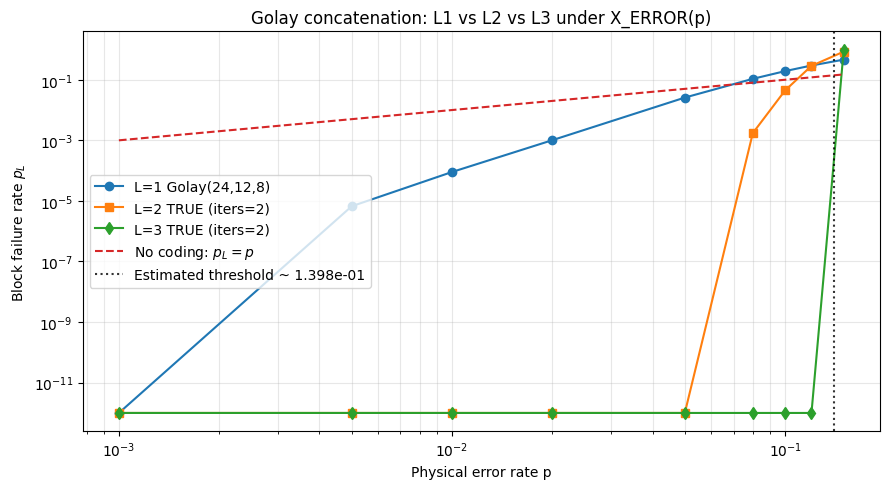

In [40]:
# True L=2 and L=3 construction:
# - L2: Golay(24,12,8) product code on a 24x24 grid
# - L3: Golay(24,12,8)^3 on a 24x24x24 cube

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Runtime knobs (L3 is expensive)
# ----------------------------
shots_L1_eval = 300_000
shots_L2_eval = 150_000
shots_L3_eval = 15_000          # keep modest for notebook runtime
iters_L2 = 2
iters_L3 = 2
batch_size_l3 = 128
batch_size = 5_000

# ----------------------------
# Run L1 / L2 / L3
# ----------------------------
pL1 = []
pL2 = []
pL3 = []

for i, p in enumerate(p_values):
    ber1 = simulate_golay24_quantum(H, corr_table, float(p), shots_L1_eval, seed=seed_base + 10_000 + i)
    ber2 = simulate_golay_product_L2_quantum(float(p), shots_L2_eval, seed=seed_base + 20_000 + i, iters=iters_L2)
    ber3 = simulate_golay_product_L3_quantum(
        float(p),
        shots_L3_eval,
        seed=seed_base + 30_000 + i,
        iters=iters_L3,
        batch_size_l3=batch_size_l3,
    )

    pL1.append(ber1)
    pL2.append(ber2)
    pL3.append(ber3)

    print(f"p={p:.3e} -> L1={ber1:.3e}, L2={ber2:.3e}, L3={ber3:.3e}")

pL1 = np.array(pL1, dtype=float)
pL2 = np.array(pL2, dtype=float)
pL3 = np.array(pL3, dtype=float)

# ----------------------------
# Threshold estimates from sampled crossings
# ----------------------------
th = estimate_physical_thresholds(p_values, pL1, pL2, pL3)
print()
print("Threshold estimates:")
for k, v in th.items():
    print(f"  {k}: {v}")

# Practical single-number estimate (priority: L2-L3 crossing)
p_th = th["cross_L2_L3"]
if p_th is None:
    p_th = th["cross_L1_L2"]
if p_th is None:
    p_th = th["pseudo_L3"]
if p_th is None:
    p_th = th["pseudo_L2"]
if p_th is None:
    p_th = th["pseudo_L1"]

print()
print(f"Estimated physical threshold p_th ~= {p_th}")

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(9, 5))
plt.loglog(p_values, np.maximum(pL1, eps), "o-", label="L=1 Golay(24,12,8)")
plt.loglog(p_values, np.maximum(pL2, eps), "s-", label=f"L=2 TRUE (iters={iters_L2})")
plt.loglog(p_values, np.maximum(pL3, eps), "d-", label=f"L=3 TRUE (iters={iters_L3})")
plt.loglog(p_values, p_values, "--", label="No coding: $p_L=p$")

if p_th is not None:
    plt.axvline(p_th, color="k", linestyle=":", alpha=0.8, label=f"Estimated threshold ~ {p_th:.3e}")

plt.xlabel("Physical error rate p")
plt.ylabel("Block failure rate $p_L$")
plt.title("Golay concatenation: L1 vs L2 vs L3 under X_ERROR(p)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



Golay fixed: [n,k,d] = [24, 12, 8] -> rate R = 0.500000

Scenario A: match rate (R_rep = R_g), evaluate distance
  exact n_rep = 1/R_g = 2.000000
  integer n_rep = 2 -> d_rep = 2, R_rep = 0.500000
  odd n_rep     = 3 -> d_rep = 3, R_rep = 0.333333
  distance gap vs Golay (odd case): d_rep - d_g = -5

Scenario B: match distance (d_rep = d_g), evaluate rate
  exact n_rep = d_g = 8 -> R_rep = 0.125000
  odd n_rep   = 9 -> R_rep = 0.111111
  rate gap vs Golay (odd case): R_rep - R_g = -0.388889


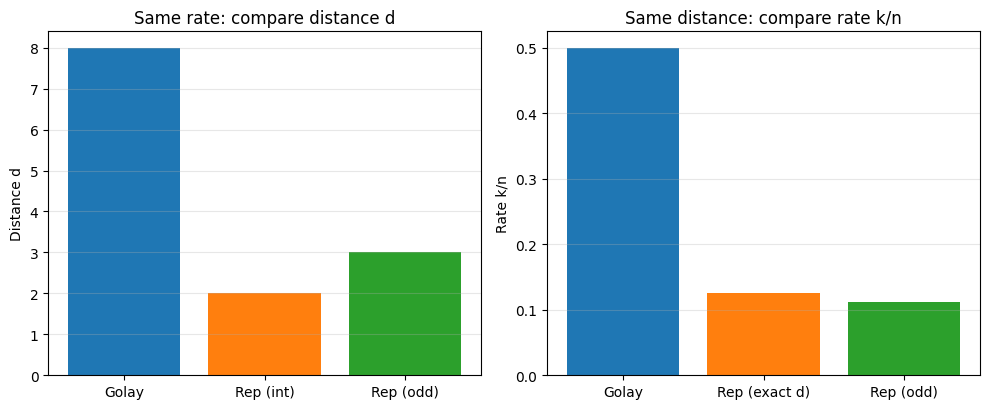

In [41]:
# Golay (fixed) vs Repetition: two parameter-matching comparisons
# Assumption: fixed Golay is extended binary Golay [24,12,8]

import numpy as np
import matplotlib.pyplot as plt

n_g, k_g, d_g = 24, 12, 8
R_g = k_g / n_g

# Repetition code model: [n_rep, 1, d_rep=n_rep], so R_rep = 1/n_rep

# ----------------------------
# 1) Match rate (R_rep = R_g), evaluate d_rep
# ----------------------------
n_rep_rate_exact = 1.0 / R_g               # may be non-odd / non-integer in general
n_rep_rate_int = int(round(n_rep_rate_exact))
if n_rep_rate_int < 1:
    n_rep_rate_int = 1

# majority decoding usually uses odd n
n_rep_rate_odd = n_rep_rate_int if (n_rep_rate_int % 2 == 1) else n_rep_rate_int + 1

R_rep_rate_int = 1.0 / n_rep_rate_int
R_rep_rate_odd = 1.0 / n_rep_rate_odd

d_rep_rate_int = n_rep_rate_int
d_rep_rate_odd = n_rep_rate_odd

# ----------------------------
# 2) Match distance (d_rep = d_g), evaluate R_rep
# ----------------------------
n_rep_d_exact = d_g
n_rep_d_odd = n_rep_d_exact if (n_rep_d_exact % 2 == 1) else n_rep_d_exact + 1

R_rep_d_exact = 1.0 / n_rep_d_exact
R_rep_d_odd = 1.0 / n_rep_d_odd

d_rep_d_exact = n_rep_d_exact
d_rep_d_odd = n_rep_d_odd

# ----------------------------
# Print summary
# ----------------------------
print("Golay fixed: [n,k,d] =", [n_g, k_g, d_g], f"-> rate R = {R_g:.6f}")
print()
print("Scenario A: match rate (R_rep = R_g), evaluate distance")
print(f"  exact n_rep = 1/R_g = {n_rep_rate_exact:.6f}")
print(f"  integer n_rep = {n_rep_rate_int} -> d_rep = {d_rep_rate_int}, R_rep = {R_rep_rate_int:.6f}")
print(f"  odd n_rep     = {n_rep_rate_odd} -> d_rep = {d_rep_rate_odd}, R_rep = {R_rep_rate_odd:.6f}")
print(f"  distance gap vs Golay (odd case): d_rep - d_g = {d_rep_rate_odd - d_g}")
print()
print("Scenario B: match distance (d_rep = d_g), evaluate rate")
print(f"  exact n_rep = d_g = {n_rep_d_exact} -> R_rep = {R_rep_d_exact:.6f}")
print(f"  odd n_rep   = {n_rep_d_odd} -> R_rep = {R_rep_d_odd:.6f}")
print(f"  rate gap vs Golay (odd case): R_rep - R_g = {R_rep_d_odd - R_g:.6f}")

# ----------------------------
# Quick visual comparison
# ----------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2))

# A: same rate -> compare distances
labels_A = ["Golay", "Rep (int)", "Rep (odd)"]
vals_A = [d_g, d_rep_rate_int, d_rep_rate_odd]
axs[0].bar(labels_A, vals_A, color=["tab:blue", "tab:orange", "tab:green"])
axs[0].set_title("Same rate: compare distance d")
axs[0].set_ylabel("Distance d")
axs[0].grid(axis="y", alpha=0.3)

# B: same distance -> compare rates
labels_B = ["Golay", "Rep (exact d)", "Rep (odd)"]
vals_B = [R_g, R_rep_d_exact, R_rep_d_odd]
axs[1].bar(labels_B, vals_B, color=["tab:blue", "tab:orange", "tab:green"])
axs[1].set_title("Same distance: compare rate k/n")
axs[1].set_ylabel("Rate k/n")
axs[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()



### Golay VS Repetition

Fixed Golay [24,12,8]:
  rate = 0.500, distance = 8
Repetition compared:
  rate-matched (approx): n=3, rate=0.333, distance=3
  distance-matched (exact): n=8, rate=0.125, distance=8

Pseudo-thresholds from p_L = p (within sampled p-range):
  Golay: 0.06833585110988778
  Repetition rate-matched (n=3): None
  Repetition distance-matched (n=8): None


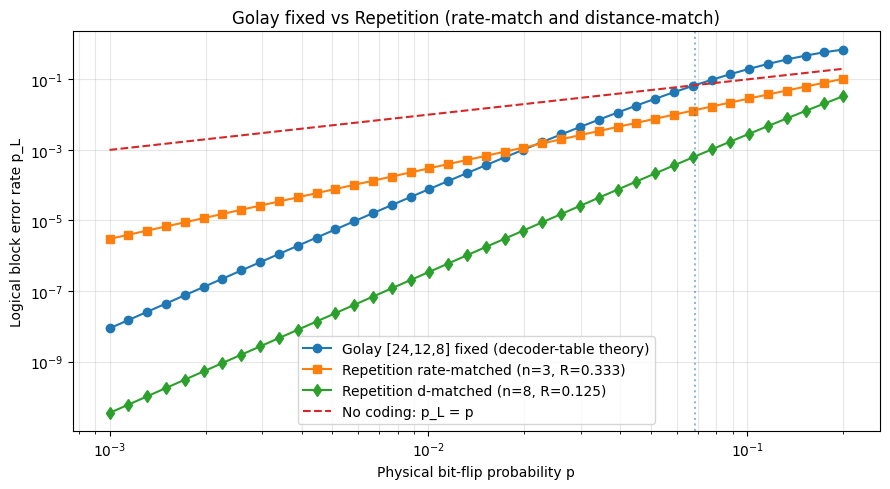

In [42]:
# Golay vs Repetition on p_L(p): include both matching criteria
# - Golay fixed: [24,12,8]
# - Repetition rate-matched: R=1/n close to Golay R=1/2 -> use n=3 (nearest odd)
# - Repetition distance-matched: d=n equal to Golay d=8 -> use n=8 (exact, even tie handled at 50%)

import numpy as np
import math
import matplotlib.pyplot as plt

n_g, k_g, d_g = 24, 12, 8
R_g = k_g / n_g

n_rep_rate = 3       # nearest odd to exact rate-matched n=2
n_rep_d = d_g        # exact distance match (n=8)

def repetition_logical_fail_prob(n: int, p: float, tie_rule: str = "half") -> float:
    """
    Logical failure for repetition [n,1,n] under majority decoding on BSC(p).

    tie_rule for even n:
      - "half": tie contributes 0.5 (unbiased tie-break)
      - "zero": tie decoded as logical 0
    """
    m = n // 2
    fail = sum(math.comb(n, w) * (p ** w) * ((1 - p) ** (n - w)) for w in range(m + 1, n + 1))

    if (n % 2 == 0):
        tie = math.comb(n, m) * (p ** m) * ((1 - p) ** (n - m))
        if tie_rule == "half":
            fail += 0.5 * tie
        elif tie_rule == "zero":
            pass
        else:
            raise ValueError("tie_rule must be 'half' or 'zero'")

    return float(fail)

# Sweep p
p_cmp = np.geomspace(1e-3, 2e-1, 40)

# Golay fixed (exact for current syndrome table decoder)
pL_golay = np.array([golay24_theory_block_fail_for_table(float(p), corr_table) for p in p_cmp], dtype=float)

# Repetition curves
pL_rep_rate = np.array([repetition_logical_fail_prob(n_rep_rate, float(p), tie_rule="half") for p in p_cmp], dtype=float)
pL_rep_d = np.array([repetition_logical_fail_prob(n_rep_d, float(p), tie_rule="half") for p in p_cmp], dtype=float)

# Optional pseudo-thresholds (p where p_L = p on sampled interval)
pth_g = estimate_curve_crossing(p_cmp, pL_golay, p_cmp)
pth_r_rate = estimate_curve_crossing(p_cmp, pL_rep_rate, p_cmp)
pth_r_d = estimate_curve_crossing(p_cmp, pL_rep_d, p_cmp)

print("Fixed Golay [24,12,8]:")
print(f"  rate = {R_g:.3f}, distance = {d_g}")
print("Repetition compared:")
print(f"  rate-matched (approx): n={n_rep_rate}, rate={1/n_rep_rate:.3f}, distance={n_rep_rate}")
print(f"  distance-matched (exact): n={n_rep_d}, rate={1/n_rep_d:.3f}, distance={n_rep_d}")
print()
print("Pseudo-thresholds from p_L = p (within sampled p-range):")
print(f"  Golay: {pth_g}")
print(f"  Repetition rate-matched (n={n_rep_rate}): {pth_r_rate}")
print(f"  Repetition distance-matched (n={n_rep_d}): {pth_r_d}")

# Plot p_L vs p
plt.figure(figsize=(9, 5))
plt.loglog(p_cmp, np.maximum(pL_golay, 1e-15), 'o-', label='Golay [24,12,8] fixed (decoder-table theory)')
plt.loglog(p_cmp, np.maximum(pL_rep_rate, 1e-15), 's-', label=f'Repetition rate-matched (n={n_rep_rate}, R={1/n_rep_rate:.3f})')
plt.loglog(p_cmp, np.maximum(pL_rep_d, 1e-15), 'd-', label=f'Repetition d-matched (n={n_rep_d}, R={1/n_rep_d:.3f})')
plt.loglog(p_cmp, p_cmp, '--', label='No coding: p_L = p')

for pth, color, name in [
    (pth_g, 'tab:blue', 'Golay'),
    (pth_r_rate, 'tab:orange', 'Rep rate-match'),
    (pth_r_d, 'tab:green', 'Rep d-match'),
]:
    if pth is not None:
        plt.axvline(pth, color=color, linestyle=':', alpha=0.5)

plt.xlabel('Physical bit-flip probability p')
plt.ylabel('Logical block error rate p_L')
plt.title('Golay fixed vs Repetition (rate-match and distance-match)')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



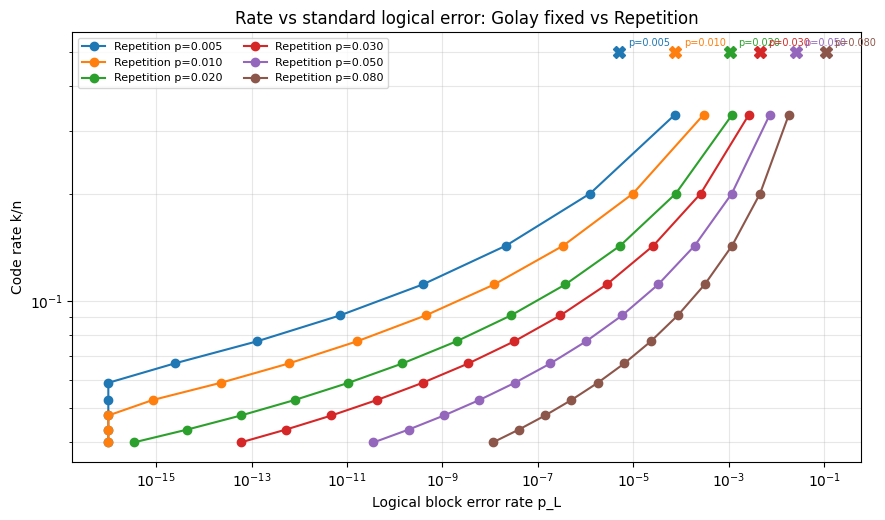

In [55]:
# Rate on Y-axis with standard logical block error rate on X-axis
# 6 curves for fixed p; Golay shown as fixed-rate marker for each p

import numpy as np
import math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

repo_root = Path.cwd()
if (repo_root / "team-quantum_icing").exists():
    sys.path.append(str(repo_root / "team-quantum_icing"))

try:
    golay24_theory_block_fail_for_table
    corr_table
except NameError:
    from golay24 import *


def repetition_logical_fail_prob(n: int, p: float, tie_rule: str = "half") -> float:
    m = n // 2
    fail = sum(math.comb(n, w) * (p ** w) * ((1 - p) ** (n - w)) for w in range(m + 1, n + 1))
    if n % 2 == 0:
        tie = math.comb(n, m) * (p ** m) * ((1 - p) ** (n - m))
        if tie_rule == "half":
            fail += 0.5 * tie
    return float(fail)


p_fixed = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08]
n_values = np.arange(3, 26, 2)

# Golay fixed [24,12,8]
n_g, k_g = 24, 12
R_g = k_g / n_g

plt.figure(figsize=(9, 5.3))

for p in p_fixed:
    # Repetition family across n
    rep_x = np.array([repetition_logical_fail_prob(int(n), float(p), tie_rule="half") for n in n_values], dtype=float)
    rep_y = 1.0 / n_values

    line = plt.loglog(np.maximum(rep_x, 1e-16), rep_y, 'o-', label=f'Repetition p={p:.3f}')[0]

    # Golay single point at same p
    g_x = golay24_theory_block_fail_for_table(float(p), corr_table)
    plt.loglog([max(g_x, 1e-16)], [R_g], marker='X', markersize=9, linestyle='None', color=line.get_color())
    plt.annotate(
        f'p={p:.3f}',
        (max(g_x, 1e-16), R_g),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=7,
        color=line.get_color(),
    )

plt.xlabel('Logical block error rate p_L')
plt.ylabel('Code rate k/n')
plt.title('Rate vs standard logical error: Golay fixed vs Repetition')
plt.grid(True, which='both', alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

In [1]:
# Unified metrics for Golay vs Repetition (fair comparison toolkit)

import numpy as np
import math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

repo_root = Path.cwd()
if (repo_root / "team-quantum_icing").exists():
    sys.path.append(str(repo_root / "team-quantum_icing"))

# Ensure Golay objects are available
try:
    H
    corr_table
except NameError:
    from golay24 import *

# Golay fixed [24,12,8]
n_g, k_g, d_g = 24, 12, 8
R_g = k_g / n_g

H_cmp = (H.copy() & 1).astype(np.uint8)
corr_bits_cmp = ((corr_table[:, None] >> np.arange(24, dtype=np.uint32)) & 1).astype(np.uint8)
w12_cmp = (1 << np.arange(12, dtype=np.uint16))


def simulate_golay24_ber_bler(p: float, shots: int = 80_000, seed: int = 0):
    """
    Monte Carlo BER_L and BLER for Golay [24,12,8] under bit-flips.

    BER_L is estimated on first 12 bits after decode, consistent with the
    systematic interpretation used in this notebook.
    """
    rng = np.random.default_rng(seed)

    e = rng.binomial(1, p, size=(shots, 24)).astype(np.uint8)
    synd = (e @ H_cmp.T) & 1
    syn_int = (synd.astype(np.uint16) @ w12_cmp).astype(np.uint16)
    e_hat = corr_bits_cmp[syn_int]

    residual = e ^ e_hat
    ber_l = float(np.mean(residual[:, :k_g]))
    bler = float(np.mean(np.any(residual, axis=1)))
    return ber_l, bler

def eta_from_ber(k: int, n: int, ber_l: np.ndarray) -> np.ndarray:
    """Throughput efficiency metric: eta(p) = (k/n)*(1-BER_L)."""
    return (k / n) * (1.0 - np.asarray(ber_l, dtype=float))



def repetition_ber_l(n: int, p: float, tie_rule: str = "half") -> float:
    """
    BER per logical bit for a repetition [n,1,n] code under majority decoding.
    Since k=1 this equals the logical block error rate.
    """
    m = n // 2
    fail = sum(math.comb(n, w) * (p ** w) * ((1 - p) ** (n - w))
               for w in range(m + 1, n + 1))
    if n % 2 == 0:
        tie = math.comb(n, m) * (p ** m) * ((1 - p) ** (n - m))
        if tie_rule == "half":
            fail += 0.5 * tie
    return float(fail)


H shape: (12, 24)
HH^T mod 2 == 0 ? True
Correction table size: 4096 (expected 4096)


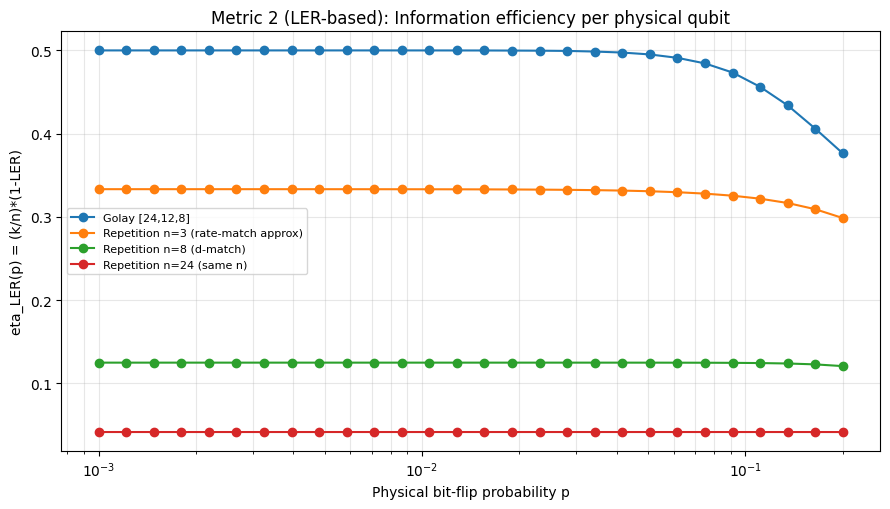

In [2]:
# Metric 2) eta_LER(p) = (k/n)*(1-LER)
# This cell computes the shared data (p_grid, code_params, ber_curves, bler_curves)
# that used to be in Metric 1.

p_grid = np.geomspace(1e-3, 2e-1, 28)

code_params = {
    'Golay [24,12,8]': {'n': 24, 'k': 12},
    'Repetition n=3 (rate-match approx)': {'n': 3, 'k': 1},
    'Repetition n=8 (d-match)': {'n': 8, 'k': 1},
    'Repetition n=24 (same n)': {'n': 24, 'k': 1},
}

ber_curves = {}
bler_curves = {}

# Golay via Monte Carlo decode
ber_g, bler_g = [], []
for i, p in enumerate(p_grid):
    b1, b2 = simulate_golay24_ber_bler(float(p), shots=80_000, seed=12000 + i)
    ber_g.append(b1)
    bler_g.append(b2)
ber_curves['Golay [24,12,8]'] = np.array(ber_g, dtype=float)
bler_curves['Golay [24,12,8]'] = np.array(bler_g, dtype=float)

# Repetition analytically exact
for name, meta in code_params.items():
    if name.startswith('Golay'):
        continue
    n = meta['n']
    ber_r = np.array([repetition_ber_l(n, float(p), tie_rule='half') for p in p_grid], dtype=float)
    ber_curves[name] = ber_r
    bler_curves[name] = ber_r  # k=1

# LER here = logical error rate per logical qubit (same quantity as BER_L in this setup)
logical_error_rate_curves = ber_curves
eta_ler_curves = {}
for name, meta in code_params.items():
    eta_ler_curves[name] = eta_from_ber(meta['k'], meta['n'], logical_error_rate_curves[name])

plt.figure(figsize=(9, 5.2))
for name, y in eta_ler_curves.items():
    plt.semilogx(p_grid, y, marker='o', label=name)

plt.xlabel('Physical bit-flip probability p')
plt.ylabel('eta_LER(p) = (k/n)*(1-LER)')
plt.title('Metric 2 (LER-based): Information efficiency per physical qubit')
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



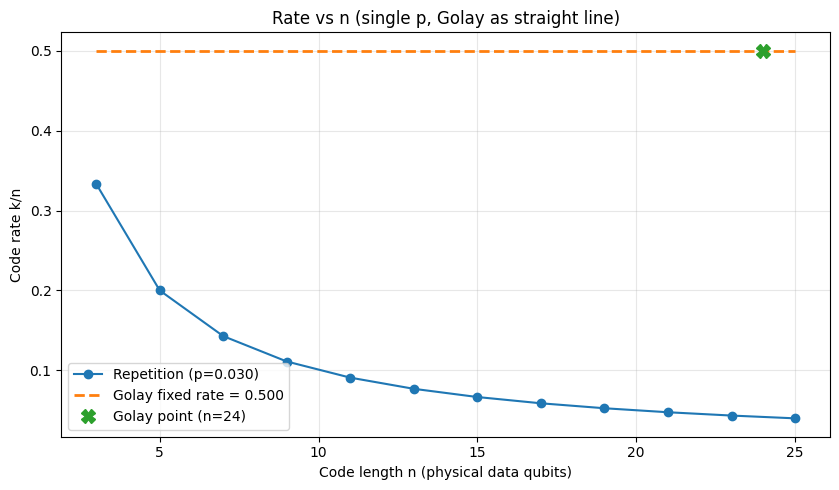

In [58]:
# Rate vs n with one fixed p and Golay as a straight line

import numpy as np
import matplotlib.pyplot as plt

# Single physical error rate (kept only for label consistency)
p_single = 0.03

# Repetition [n,1,n] -> rate = 1/n
n_values = np.arange(3, 26, 2)
rep_rate = 1.0 / n_values

# Golay fixed [24,12,8]
n_g, k_g = 24, 12
R_g = k_g / n_g

plt.figure(figsize=(8.5, 5))

# Repetition curve (single p)
plt.plot(n_values, rep_rate, 'o-', label=f'Repetition (p={p_single:.3f})')

# Golay straight horizontal line across the full n-range
golay_line = np.full_like(n_values, R_g, dtype=float)
plt.plot(n_values, golay_line, '--', linewidth=2.0, label=f'Golay fixed rate = {R_g:.3f}')

# Highlight actual Golay operating point at n=24
plt.plot([n_g], [R_g], marker='X', markersize=10, linestyle='None', label='Golay point (n=24)')

plt.xlabel('Code length n (physical data qubits)')
plt.ylabel('Code rate k/n')
plt.title('Rate vs n (single p, Golay as straight line)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## LDPC

In [44]:
!pip install ldpc
!pip install stimbposd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 11.4 MB/s  0:00:001.8 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [ldpc]━━━━━━ 4/5 [ldpc]t]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [45]:
from ldpc_random import *


### Circuital Idea

Here is a simple ldpc circuit just to give an idea!

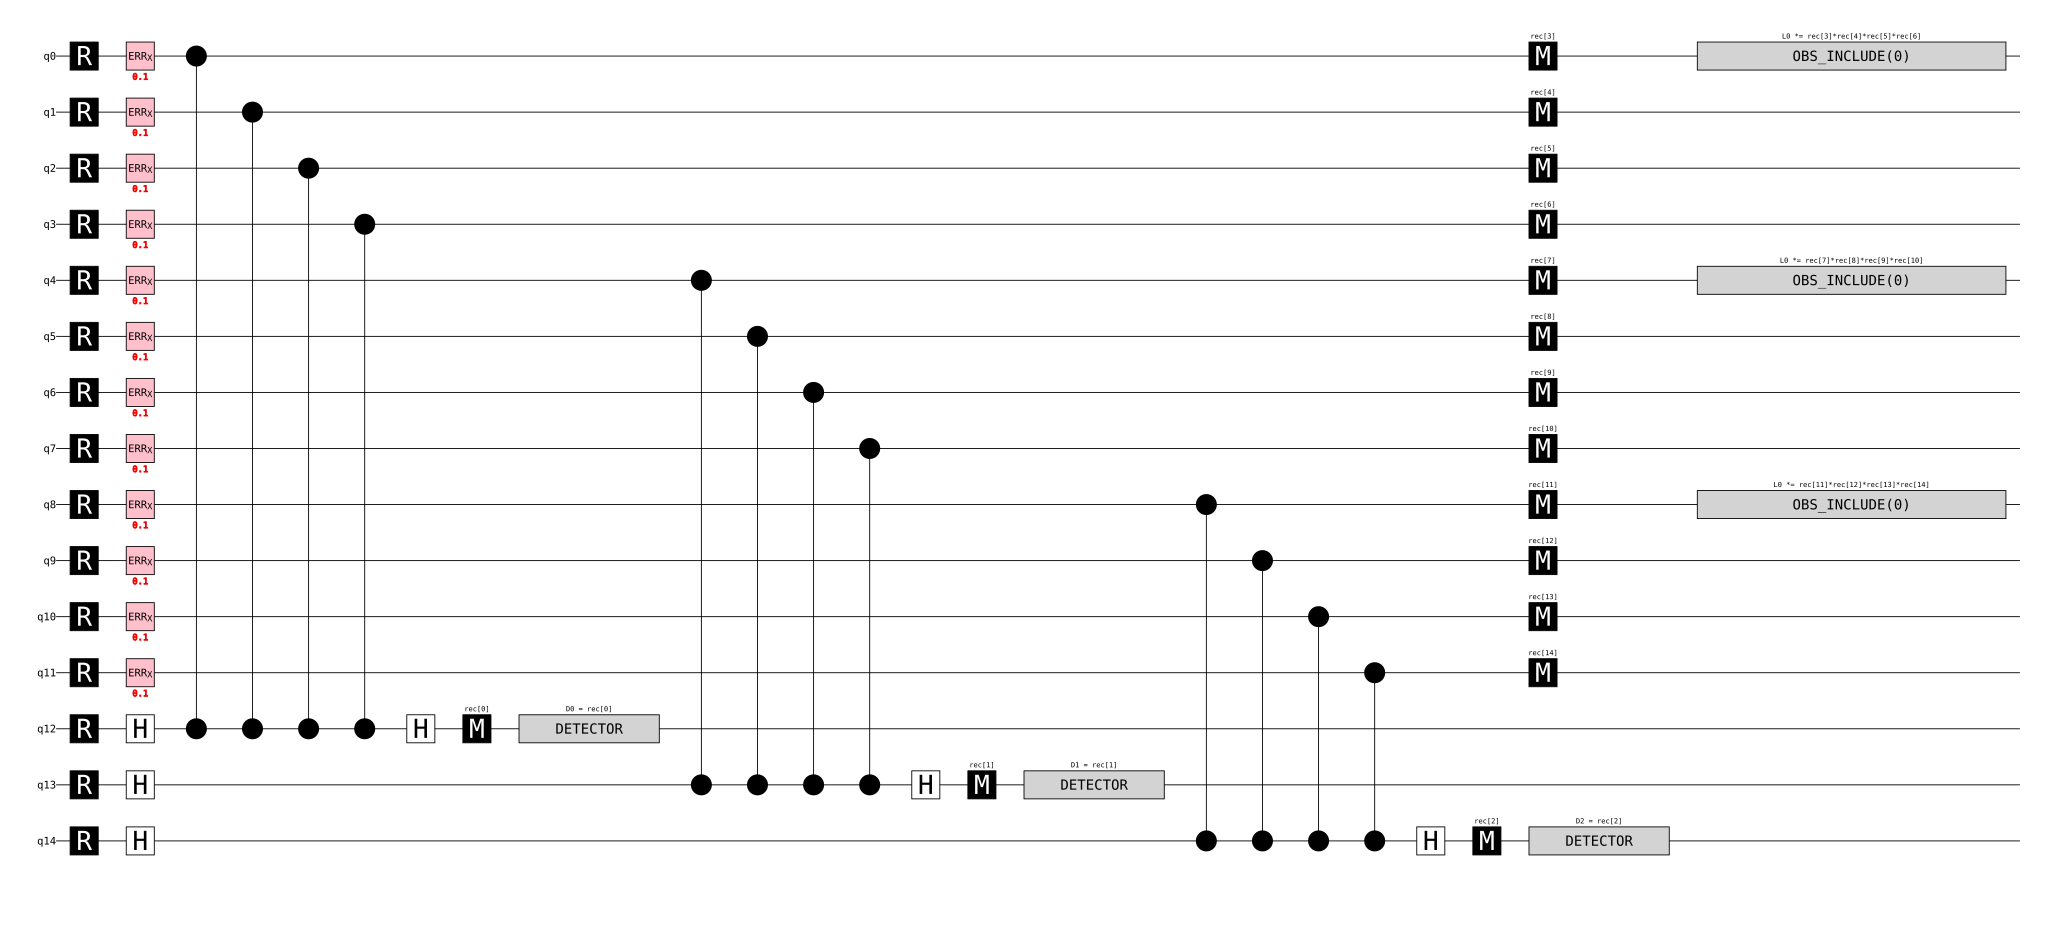

In [46]:
c = gen_simple_ldpc_circuit(12,9,1,4, 0.1)
c.diagram('timeline-svg')

### LDPC: Quantum Sim vs Theory + Logical vs Physical

Analogous to the Golay plots: we simulate the LDPC codes at several physical error rates $p$, compare with a theoretical bound, and show the logical vs physical error rate.

LDPC n=20, p=0.010 -> block error rate = 2.0000e-05  (20/1000000)
LDPC n=20, p=0.050 -> block error rate = 3.0151e-03  (501/166161)
LDPC n=20, p=0.001 -> block error rate = 0.0000e+00  (0/1000000)
LDPC n=20, p=0.005 -> block error rate = 2.0000e-06  (2/1000000)
LDPC n=20, p=0.120 -> block error rate = 4.4899e-02  (518/11537)
LDPC n=20, p=0.100 -> block error rate = 2.6205e-02  (517/19729)
LDPC n=20, p=0.080 -> block error rate = 1.3760e-02  (511/37137)
LDPC n=20, p=0.020 -> block error rate = 1.4100e-04  (141/1000000)
LDPC n=20, p=0.150 -> block error rate = 8.5710e-02  (550/6417)
LDPC n=60, p=0.001 -> block error rate = 1.0000e-06  (1/1000000)
LDPC n=60, p=0.005 -> block error rate = 6.9000e-05  (69/1000000)
LDPC n=60, p=0.010 -> block error rate = 4.5700e-04  (457/1000000)
LDPC n=60, p=0.020 -> block error rate = 2.4285e-03  (503/207121)
LDPC n=60, p=0.050 -> block error rate = 3.8057e-02  (517/13585)
LDPC n=60, p=0.080 -> block error rate = 1.5665e-01  (524/3345)
LDPC n=60, p=0.100 

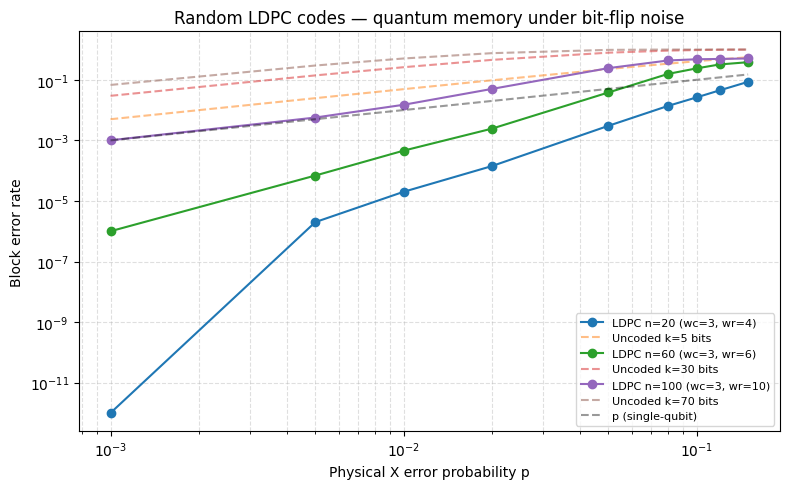

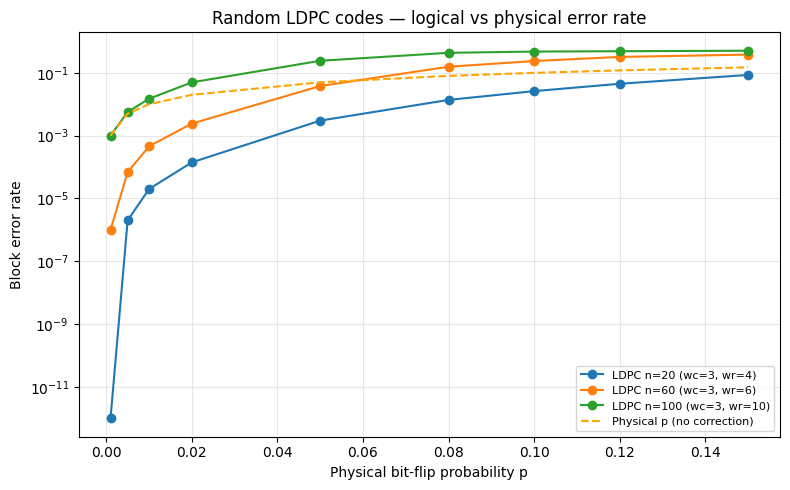

In [ ]:
import math
from stimbposd import sinter_decoders

# ── Parameters ──
p_values_ldpc = [0.001, 0.005, 0.01, 0.02, 0.05, 0.08, 0.10, 0.12, 0.15]
shots_ldpc = 1_000_000

# ── Build LDPC matrices (fixed seeds for reproducibility) ──
np.random.seed(42)
H_d20  = gen_dynamic_ldpc_matrix(20, 3, 4)    # n=20,  m=15
H_d60  = gen_dynamic_ldpc_matrix(60, 3, 6)    # n=60,  m=30
H_d100 = gen_dynamic_ldpc_matrix(100, 3, 10)  # n=100, m=30

ldpc_configs = [
    (20,  H_d20,  3, 4),
    (60,  H_d60,  3, 6),
    (100, H_d100, 3, 10),
]

# ── Simulate with sinter + bposd ──
ldpc_tasks = [
    sinter.Task(
        circuit=gen_ldpc_circuit(var_h, noise),
        json_metadata={'n': n, 'p': noise, 'wc': wc, 'wr': wr},
    )
    for n, var_h, wc, wr in ldpc_configs
    for noise in p_values_ldpc
]

ldpc_stats = sinter.collect(
    num_workers=os.cpu_count(),
    max_shots=shots_ldpc,
    max_errors=500,
    tasks=ldpc_tasks,
    decoders=['bposd'],
    custom_decoders=sinter_decoders(),
)

# ── Extract results indexed by (n, p) ──
ldpc_results = {}
for st in ldpc_stats:
    n = st.json_metadata['n']
    p = st.json_metadata['p']
    bler = st.errors / st.shots if st.shots > 0 else 0.0
    ldpc_results[(n, p)] = bler
    print(f"LDPC n={n}, p={p:.3f} -> block error rate = {bler:.4e}  ({st.errors}/{st.shots})")

# ── Theory bound: for a [n, k, d] code correcting t = floor((d-1)/2) errors ──
# The distance of random LDPC codes is not known analytically in general,
# but we use the simulated data directly. For reference we plot the
# "uncoded" line p_L = 1 - (1-p)^k  ≈ k*p for small p (k logical bits, any one fails).
def uncoded_block_fail(k, p):
    """Probability that at least one of k bits has an error."""
    return 1.0 - (1.0 - p)**k

# Approximate k for each code: k = n - rank(H) ≈ n - m
k_approx = {20: 5, 60: 30, 100: 70}

# ── Plot 1: Quantum sim — block error rate vs physical p (per code size) ──
fig1, ax1 = plt.subplots(figsize=(8, 5))
p_arr = np.array(p_values_ldpc)

for n, _, wc, wr in ldpc_configs:
    bler_sim = [ldpc_results.get((n, p), 0.0) for p in p_values_ldpc]
    ax1.loglog(p_arr, [max(b, 1e-12) for b in bler_sim], 'o-',
               label=f'LDPC n={n} (wc={wc}, wr={wr})')
    # uncoded reference for k logical bits
    k = k_approx[n]
    bler_uncoded = [uncoded_block_fail(k, p) for p in p_values_ldpc]
    ax1.loglog(p_arr, bler_uncoded, '--', alpha=0.5,
               label=f'Uncoded k={k} bits')

ax1.loglog(p_arr, p_arr, 'k--', alpha=0.4, label='p (single-qubit)')
ax1.set_xlabel('Physical X error probability p')
ax1.set_ylabel('Block error rate')
ax1.set_title('Random LDPC codes — quantum memory under bit-flip noise')
ax1.grid(True, which='both', ls='--', alpha=0.4)
ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Plot 2: Logical vs physical for each LDPC code (semilogy) ──
fig2, ax2 = plt.subplots(figsize=(8, 5))
for n, _, wc, wr in ldpc_configs:
    bler_sim = [ldpc_results.get((n, p), 0.0) for p in p_values_ldpc]
    ax2.semilogy(p_arr, [max(b, 1e-12) for b in bler_sim], 'o-',
                 label=f'LDPC n={n} (wc={wc}, wr={wr})')

ax2.semilogy(p_arr, p_arr, '--', color='orange', label='Physical p (no correction)')
ax2.set_xlabel('Physical bit-flip probability p')
ax2.set_ylabel('Block error rate')
ax2.set_title('Random LDPC codes — logical vs physical error rate')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

### LDPC fixed vs Repetition: rate-matched and distance-matched comparison

We compare a fixed LDPC code (n=60, k≈30, wc=3, wr=6) against repetition codes matched either by encoding rate or by code distance, analogous to the Golay vs Repetition comparison.

LDPC [60, ≈30] — estimated d ≥ 2  (heuristic from kernel basis)

LDPC n=60, k≈30, R≈0.500, d≈2
Rate-matched rep: n_rep=3 (closest odd), R=0.333
Distance-matched rep: n_rep=3 (odd, d=3), R=0.3333


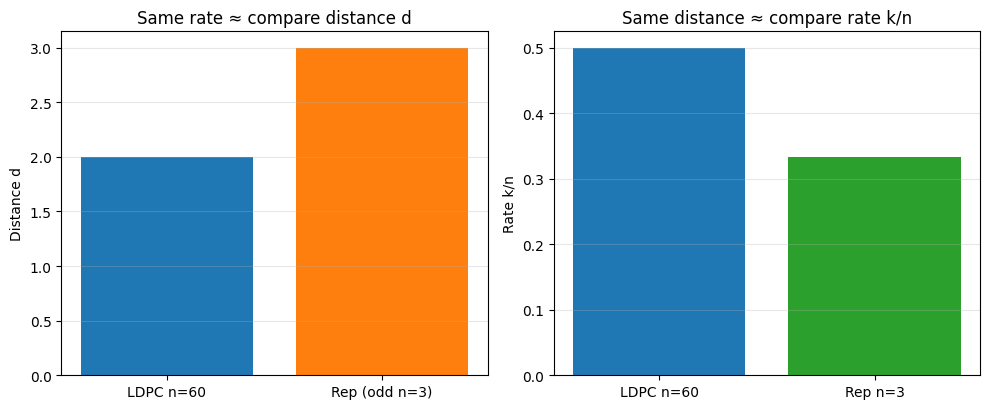

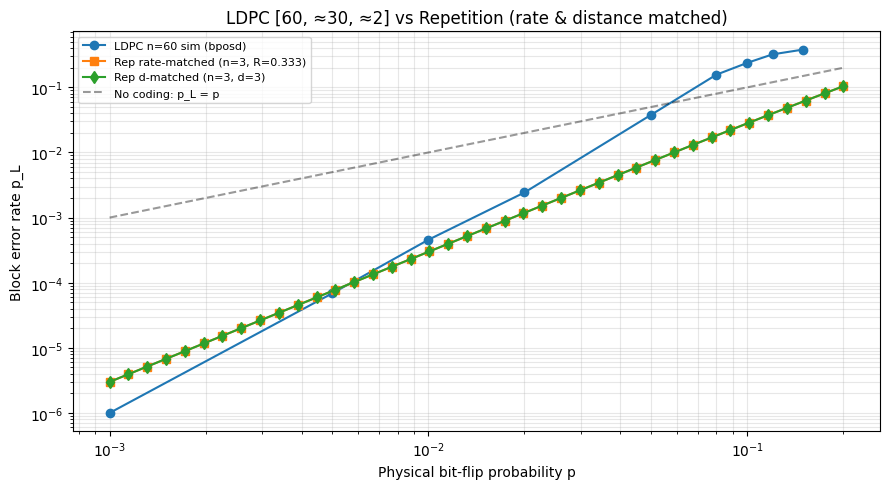

In [ ]:
# ── LDPC vs Repetition: rate-matched & distance-estimated comparison ──
# We pick the LDPC n=60 code as the "fixed" code (analogous to Golay [24,12,8]).
# The sim data comes from the previous cell (ldpc_results dict).

import math
import numpy as np
import matplotlib.pyplot as plt

# ── Code parameters ──
n_ldpc, wc_ldpc, wr_ldpc = 60, 3, 6
k_ldpc = k_approx[n_ldpc]           # ≈ 30
R_ldpc = k_ldpc / n_ldpc            # ≈ 0.5

# ── Estimate minimum distance from kernel of H ──
# For random regular LDPC codes d is not analytically known;
# we check all kernel basis vectors + their pairwise XOR sums
# as a practical lower-bound heuristic.
from ldpc import mod2

kernel = mod2.nullspace(H_d60)
k_rows = kernel.shape[0]
weights = []
for i in range(k_rows):
    w = int(kernel[i].toarray().sum())
    if w > 0:
        weights.append(w)
# pairwise XOR
for i in range(min(k_rows, 200)):
    for j in range(i + 1, min(k_rows, 200)):
        combo = (kernel[i] + kernel[j]).toarray().flatten() % 2
        w = int(combo.sum())
        if w > 0:
            weights.append(w)

d_est = min(weights) if weights else n_ldpc
print(f"LDPC [{n_ldpc}, ≈{k_ldpc}] — estimated d ≥ {d_est}  (heuristic from kernel basis)")

# ── Rate-matched repetition code ──
# Rep [n_rep, 1, n_rep] has R=1/n_rep.  Match R_ldpc ≈ 0.5 → n_rep = ceil(1/R_ldpc) = 2
n_rep_rate_exact = 1.0 / R_ldpc           # = 2.0
n_rep_rate_int = max(2, int(round(n_rep_rate_exact)))
n_rep_rate_odd = n_rep_rate_int if n_rep_rate_int % 2 == 1 else n_rep_rate_int + 1

# ── Distance-matched repetition code ──
n_rep_d_exact = d_est
n_rep_d_odd = n_rep_d_exact if n_rep_d_exact % 2 == 1 else n_rep_d_exact + 1

print(f"\nLDPC n={n_ldpc}, k≈{k_ldpc}, R≈{R_ldpc:.3f}, d≈{d_est}")
print(f"Rate-matched rep: n_rep={n_rep_rate_odd} (closest odd), R={1/n_rep_rate_odd:.3f}")
print(f"Distance-matched rep: n_rep={n_rep_d_odd} (odd, d={n_rep_d_odd}), R={1/n_rep_d_odd:.4f}")

# ── Sweep p_L ──
p_cmp = np.geomspace(1e-3, 2e-1, 40)

# LDPC sim points from previous cell (interpolate for nice curve)
p_ldpc_sim = np.array(p_values_ldpc)
bler_ldpc_sim = np.array([ldpc_results.get((n_ldpc, p), 0.0) for p in p_values_ldpc])

# Repetition analytical
pL_rep_rate = np.array([repetition_logical_fail_prob(n_rep_rate_odd, float(p)) for p in p_cmp])
pL_rep_d    = np.array([repetition_logical_fail_prob(n_rep_d_odd, float(p)) for p in p_cmp])

# ── Bar charts: same rate → compare d;  same d → compare rate ──
fig_bar, axs = plt.subplots(1, 2, figsize=(10, 4.2))

labels_A = [f"LDPC n={n_ldpc}", f"Rep (odd n={n_rep_rate_odd})"]
vals_A   = [d_est, n_rep_rate_odd]
axs[0].bar(labels_A, vals_A, color=["tab:blue", "tab:orange"])
axs[0].set_title("Same rate ≈ compare distance d")
axs[0].set_ylabel("Distance d")
axs[0].grid(axis="y", alpha=0.3)

labels_B = [f"LDPC n={n_ldpc}", f"Rep n={n_rep_d_odd}"]
vals_B   = [R_ldpc, 1/n_rep_d_odd]
axs[1].bar(labels_B, vals_B, color=["tab:blue", "tab:green"])
axs[1].set_title("Same distance ≈ compare rate k/n")
axs[1].set_ylabel("Rate k/n")
axs[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ── p_L  vs  p  comparison plot ──
fig_cmp, ax_cmp = plt.subplots(figsize=(9, 5))

# LDPC simulated (markers)
ax_cmp.loglog(p_ldpc_sim, np.maximum(bler_ldpc_sim, 1e-15), 'o-',
              label=f'LDPC n={n_ldpc} sim (bposd)')

# Repetition analytical
ax_cmp.loglog(p_cmp, np.maximum(pL_rep_rate, 1e-15), 's-',
              label=f'Rep rate-matched (n={n_rep_rate_odd}, R={1/n_rep_rate_odd:.3f})')
ax_cmp.loglog(p_cmp, np.maximum(pL_rep_d, 1e-15), 'd-',
              label=f'Rep d-matched (n={n_rep_d_odd}, d={n_rep_d_odd})')

# No-coding reference
ax_cmp.loglog(p_cmp, p_cmp, 'k--', alpha=0.4, label='No coding: p_L = p')

ax_cmp.set_xlabel('Physical bit-flip probability p')
ax_cmp.set_ylabel('Block error rate p_L')
ax_cmp.set_title(f'LDPC [{n_ldpc}, ≈{k_ldpc}, ≈{d_est}] vs Repetition (rate & distance matched)')
ax_cmp.grid(True, which='both', alpha=0.3)
ax_cmp.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Adding a bit of randomization to the parity matrix

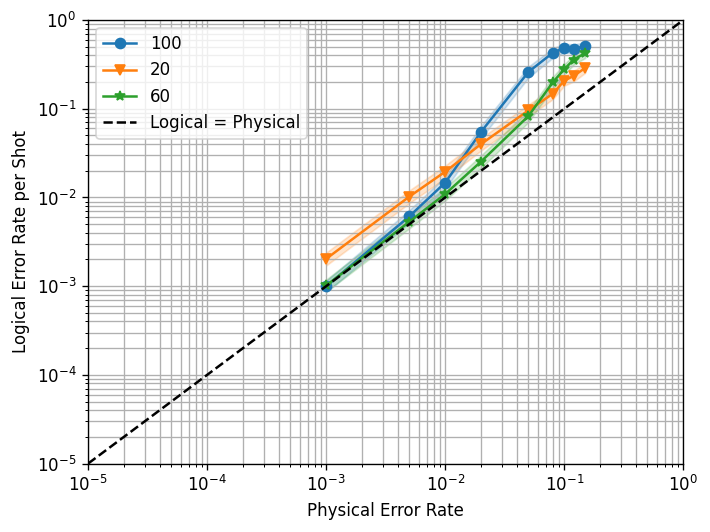

In [51]:
samples = ldpc_demo()
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=samples,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)

x_vals = np.logspace(-5, 0, 100) # Match the range of your x-axis
ax.plot(x_vals, x_vals, color='black', linestyle='--', label='Logical = Physical')

ax.set_ylim(1e-5, 1e-0)
ax.set_xlim(1e-5, 1e-0)
ax.loglog()
# ax.set_title("Repetition Code Error Rates (Phenomenological Noise)")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.set_dpi(120)  # Show it bigger